# **02477 — Task-Type Guide**

Every question across all 4 exams belongs to one of **14 task types**. This file tells you, for each type: what the question is actually asking, the universal recipe to solve it, and which exams used it.

---

## The 14 Task Types

| # | Task Type | Appears in |
|---|-----------|------------|
| 1 | **Determine a distribution** (likelihood, prior, conditional, marginal, posterior) | All 4 exams |
| 2 | **Compute a predictive distribution** (prior predictive or posterior predictive) | All 4 exams |
| 3 | **Compute the MLE** | May 2024, Aug 2024R, May 2025, Aug 2025R |
| 4 | **Evaluate log joint / log marginal likelihood** | All 4 exams |
| 5 | **Compute a credibility interval or tail probability** | All 4 exams |
| 6 | **Compute the Hessian / Laplace approximation** | May 2024, Aug 2025R |
| 7 | **Compute entropy / confidence of a distribution** | May 2024, Aug 2024R, May 2025, Aug 2025R |
| 8 | **MC estimation from MCMC samples** (mean, probability, interval) | All 4 exams |
| 9 | **Run and report a Metropolis sampler** | All 4 exams |
| 10 | **Grid approximation** (posterior mean, variance, predictive) | May 2025 |
| 11 | **Reasoning about model changes** (effect of hyperparameter, switching kernel, family) | All 4 exams |
| 12 | **Identify / verify the MAP** | May 2024, Aug 2025R |
| 13 | **Identify a model** (prior, likelihood, stationarity, link function) | Aug 2024R, Aug 2025R |
| 14 | **Decision theory** (expected utility, optimal action) | May 2024 |

---

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal as mvn, poisson
np.random.seed(42)

# ── Helpers used everywhere ───────────────────────────────────────────────────
sigmoid  = lambda a: 1.0 / (1.0 + np.exp(-a))
softmax  = lambda f: np.exp(f - np.max(f)) / np.sum(np.exp(f - np.max(f)))
log_npdf = lambda x, m, v: -0.5*np.log(2*np.pi*v) - 0.5*(x-m)**2/v
npdf     = lambda x, m, v: np.exp(log_npdf(x, m, v))
log_ber  = lambda y, p: y*np.log(np.clip(p,1e-12,1)) + (1-y)*np.log(np.clip(1-p,1e-12,1))
H_disc   = lambda p: -np.sum(p[p>0]*np.log(p[p>0]))   # entropy of discrete distribution
print("Helpers ready — run this cell first.")


Helpers ready — run this cell first.


## Task Type 1 — Determine a Distribution

### What the question looks like
- *"Determine the distribution $p(z|x)$"*
- *"Determine the analytical distribution $p(y|w, \Phi)$"*
- *"Determine the posterior distribution $p(w|y)$"*
- *"Determine the marginal distribution $p(x_3)$"*
- *"Show that $p(y|v)$ is a Gaussian mixture"*
- *"Determine the prior distribution $p(f^*)$"*

**Appears in:** May 2024 Q1.1–1.3, Q2.1, Q2.2, Q4.1–4.2 | Aug 2024R Q2.2–2.3 | May 2025 Q1.1, Q1.3, Q3.1–3.2, Q4.1 | Aug 2025R Q1.1–1.3, Q3.1–3.2

---

### Universal recipe

**Step 1 — Identify what type of distribution is being asked for:**

| Asked for | Strategy |
|-----------|----------|
| $p(y\|w)$ — likelihood | Read off model: $y_n = f(x_n) + \epsilon_n$ with $\epsilon\sim\mathcal{N}(0,\sigma^2)$ gives $p(y\|w)=\mathcal{N}(y\|\Phi w,\sigma^2 I)$ |
| $p(z\|x)$ — direct conditional | Read off: $z=Ax+b+n_1$, $n_1\sim\mathcal{N}(0,\Sigma_1)$ gives $p(z\|x)=\mathcal{N}(z\|Ax+b,\Sigma_1)$ |
| $p(x\|z)$ — reverse conditional | Linear Gaussian posterior formulas (see below) |
| $p(x_3)$ — marginal | Marginalisation formula (see below) |
| $p(f^*)$ — GP prior | $p(f^*)=\mathcal{N}(f^*\|0, k(x^*,x^*))$ — just evaluate the kernel at the test point |
| $p(f\|x)$ — GP prior at training points | $p(f\|x)=\mathcal{N}(f\|0,K)$ — build the kernel matrix |
| $p(f\|y,x)$ — GP posterior | Use posterior mean/cov formulas |
| $p(w\|y)$ — Bayesian linear regression posterior | Conjugate formula |
| $p(y\|v)$ — mixture model | Sum over discrete variable using sum rule |

**Step 2 — Apply the right formula:**

### Direct conditional (z = Ax + b + noise)
$$\boxed{p(z|x) = \mathcal{N}(z\,|\,Ax+b,\;\Sigma_1)}$$
No calculation needed — just read the mean (the deterministic part) and covariance (the noise).

### Reverse conditional — Linear Gaussian posterior
Given $p(z|x)=\mathcal{N}(z|Ax+b,\Sigma_1)$ and $p(x)=\mathcal{N}(x|\mu_x,\Sigma_x)$:
$$\boxed{S^{-1} = \Sigma_x^{-1} + A^T\Sigma_1^{-1}A}$$
$$\boxed{m = S\left[A^T\Sigma_1^{-1}(z-b) + \Sigma_x^{-1}\mu_x\right]}$$
$$p(x|z) = \mathcal{N}(x|m,S)$$

**Common shortcut:** If $\Sigma_x = I$, $\mu_x=0$, $b=0$: $S^{-1}=I+A^T\Sigma_1^{-1}A$, $m=SA^T\Sigma_1^{-1}z$.

### Marginalisation — Linear Gaussian
Given $p(y|z)=\mathcal{N}(y|Wz+b,\Sigma_y)$ and $p(z)=\mathcal{N}(z|\mu_z,\Sigma_z)$:
$$\boxed{p(y) = \mathcal{N}(y\,|\,W\mu_z+b,\;\Sigma_y+W\Sigma_z W^T)}$$
Repeat for multi-step chains: first find $p(z)$, then use it to find $p(y)$.

### Bayesian linear regression posterior
Given $p(y|w)=\mathcal{N}(y|\Phi w,\sigma^2 I)$ and $p(w)=\mathcal{N}(w|0,\alpha^{-1}I)$:
$$\boxed{S = \left(\alpha I + \frac{1}{\sigma^2}\Phi^T\Phi\right)^{-1}, \qquad m = \frac{1}{\sigma^2}S\Phi^Ty}$$
$$p(w|y) = \mathcal{N}(w|m,S)$$

### Mixture model: marginalise discrete variable
Sum over all values of the discrete variable using the sum rule:
$$p(y|v) = \sum_{s\in\{0,1\}} p(y|v,s)\,p(s)$$
For each term, identify the mean and variance, then weight by $p(s)$.

### GP prior at test point
$$p(f^*) = \mathcal{N}(f^*|0,\,k(x^*,x^*))$$
At $x^*=x^{*'}$: $k(x^*,x^*)=\kappa^2\exp(0)=\kappa^2$ for SE kernel.

---

### Common mistakes
- **Reverse conditional:** forgetting to invert $S^{-1}$ to get $S$ — always solve for $S$ first, then compute $m$
- **Marginalisation:** confusing $\Sigma_y$ (noise in $y$) with $\Sigma_z$ (spread of $z$) — both contribute to the marginal covariance
- **Mixture:** confusing $p(y|v,s)$ (still depends on $v$) with $p(y|s)$ (after integrating $v$ out)

In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  TASK TYPE 1 — Determine a Distribution                      ║
# ║  Change the INPUTS block. Run. Read the result.              ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Choose which sub-case applies ────────────────────────────────────────────
# 1a: Direct conditional  p(z|x)  from  z = Ax + b + n,  n ~ N(0, Sigma1)
# 1b: Reverse conditional p(x|z)  (linear Gaussian posterior)
# 1c: Marginal p(y)       through chain  x -> z -> y
# 1d: Bayesian linear regression posterior  p(w|y)
# 1e: GP prior distribution  p(f|x) = N(f|0, K)
# 1f: Mixture discrete marginalisation  p(y|v) = sum_s p(y|v,s)*p(s)

# ══════════════════════════════════════════════════════════════
# 1a — Direct conditional  p(z|x) = N(z | Ax + b, Sigma1)
# ══════════════════════════════════════════════════════════════
print("=" * 60)
print("1a — Direct conditional p(z|x)")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
A1a    = np.array([[0.,1.],[1.,0.]])   # matrix in  z = Ax + b + n
b1a    = np.array([1., 1.])
Sigma1a= 0.5 * np.eye(2)             # noise covariance of n1
x_val  = np.array([1., 2.])          # observed x (just for showing the mean)
# ── RESULT ───────────────────────────────────────────────────
print(f"p(z|x) = N(z | Ax+b, Sigma1)")
print(f"  Mean  = A*x + b = {A1a @ x_val + b1a}")
print(f"  Cov   = Sigma1  = {Sigma1a}")
print("  (No calculation needed — just read off the model.)")

# ══════════════════════════════════════════════════════════════
# 1b — Reverse conditional  p(x|z) via linear Gaussian posterior
# ══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("1b — Reverse conditional p(x|z)")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
A1b     = np.array([[0.,1.],[1.,0.]])  # from z = Ax + b + n1
b1b     = np.array([1., 1.])
Sigma1b = 0.5 * np.eye(2)            # noise cov of z  (1/2*I in 2025R exam)
Sigma_x = np.eye(2)                  # prior cov of x
mu_x    = np.zeros(2)                # prior mean of x
z_obs   = np.array([2., 3.])         # observed z value
# ── CALCULATION ──────────────────────────────────────────────
S_inv_1b = np.linalg.inv(Sigma_x) + A1b.T @ np.linalg.inv(Sigma1b) @ A1b
S_1b     = np.linalg.inv(S_inv_1b)
m_1b     = S_1b @ (A1b.T @ np.linalg.inv(Sigma1b) @ (z_obs - b1b)
                   + np.linalg.inv(Sigma_x) @ mu_x)
print(f"S^-1 = Sigma_x^-1 + A^T Sigma1^-1 A = {np.round(S_inv_1b,4)}")
print(f"S    = inv(S^-1)                     = {np.round(S_1b,4)}")
print(f"m    = S[A^T Sigma1^-1(z-b) + ...]  = {np.round(m_1b,4)}")
print(f"p(x|z) = N(x | {np.round(m_1b,4)}, {np.round(S_1b,4)})")

# ══════════════════════════════════════════════════════════════
# 1c — Marginal p(y) through chain x -> z -> y
# ══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("1c — Marginal p(y) through chain x -> z -> y")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
A1c      = np.array([[0.,1.],[1.,0.]])  # x -> z
b1c      = np.array([1., 1.])
Sigma_x1c= np.eye(2); mu_x1c = np.zeros(2)
Sigma1c  = 0.5*np.eye(2)              # noise cov of z
W1c      = np.array([[1.,1.],[1.,0.]])  # z -> y
Sigma2c  = 0.5*np.eye(2)              # noise cov of y
# ── CALCULATION ──────────────────────────────────────────────
mu_z1c    = A1c @ mu_x1c + b1c
Sigma_z1c = Sigma1c + A1c @ Sigma_x1c @ A1c.T
mu_y1c    = W1c @ mu_z1c
Sigma_y1c = Sigma2c + W1c @ Sigma_z1c @ W1c.T
print(f"Step 1 — p(z): mu_z={np.round(mu_z1c,4)}, Sigma_z={np.round(Sigma_z1c,4)}")
print(f"Step 2 — p(y): mu_y={np.round(mu_y1c,4)}, Sigma_y={np.round(Sigma_y1c,4)}")
print(f"p(y) = N(y | {np.round(mu_y1c,4)}, {np.round(Sigma_y1c,4)})")

# ══════════════════════════════════════════════════════════════
# 1d — Bayesian linear regression posterior  p(w|y) = N(w|m,S)
# ══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("1d — Bayesian linear regression posterior p(w|y)")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
x_data = np.array([0., 1., 2., 4., 5.])
y_data = np.array([1., 0.5, -0.1, -0.9, 1.1])
alpha  = 1/2        # prior precision  (prior var = 1/alpha)
sigma  = 1/5        # noise std dev
phi    = lambda x: np.array([1, x, x**2, x**3])    # feature map — change this
Phi    = np.vstack([phi(xi) for xi in x_data])
# ── CALCULATION ──────────────────────────────────────────────
D      = Phi.shape[1]
w_MLE  = np.linalg.solve(Phi.T@Phi, Phi.T@y_data)
S_inv_1d = alpha*np.eye(D) + (1/sigma**2)*Phi.T@Phi
S_1d   = np.linalg.inv(S_inv_1d)
m_1d   = (1/sigma**2)*S_1d@Phi.T@y_data
print(f"w_MLE  = {np.round(w_MLE, 4)}")
print(f"m_post = {np.round(m_1d, 4)}")
print(f"S_post diagonal = {np.round(np.diag(S_1d), 6)}")
print(f"p(w|y) = N(w | m_post, S_post)")

# ══════════════════════════════════════════════════════════════
# 1e — GP prior distribution  p(f|x) = N(f|0, K)
# ══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("1e — GP prior distribution p(f|x) = N(f|0, K)")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
x_gp  = np.array([-2., 0., 2.])
kappa = np.sqrt(2); ell = 2.0       # kernel hyperparameters
x_star_e = 4.0                      # test point for prior variance
# ── CALCULATION ──────────────────────────────────────────────
K_e   = kappa**2*np.exp(-0.5*(x_gp[:,None]-x_gp[None,:])**2/ell**2) + 1e-8*np.eye(len(x_gp))
k_ss_e= kappa**2*np.exp(-0.5*(x_star_e-x_star_e)**2/ell**2)  # = kappa^2
print("K (prior cov at training points) =")
print(np.round(K_e,4))
print(f"p(f|x) = N(f | 0, K)")
print(f"Prior variance at x*={x_star_e}: k(x*,x*) = kappa^2 = {k_ss_e:.4f}")
print(f"Prior predictive: p(y*=0|x*) = 0.5  (zero-mean GP is symmetric)")

# ══════════════════════════════════════════════════════════════
# 1f — Mixture model: marginalise discrete s
# ══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("1f — Mixture model: p(y|v) by summing over s")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
sigma2_f = 1.0   # base noise variance (s=0)
tau2_f   = 2.0   # extra variance when s=1
p_s1_f   = 1/4   # P(s=1)
# ── RESULT ───────────────────────────────────────────────────
print(f"p(y|v) = (1-p)*N(y|v, sigma^2) + p*N(y|v, sigma^2+tau^2)")
print(f"       = {1-p_s1_f:.2f}*N(y|v, {sigma2_f}) + {p_s1_f:.2f}*N(y|v, {sigma2_f+tau2_f})")
print(f"Weights: {1-p_s1_f:.4f} and {p_s1_f:.4f}  (must sum to 1: {1-p_s1_f+p_s1_f:.2f})")
print(f"Means:   both = v  (same mean, different variance)")
print(f"Variances: {sigma2_f} and {sigma2_f+tau2_f}")


1a — Direct conditional p(z|x)
p(z|x) = N(z | Ax+b, Sigma1)
  Mean  = A*x + b = [3. 2.]
  Cov   = Sigma1  = [[0.5 0. ]
 [0.  0.5]]
  (No calculation needed — just read off the model.)

1b — Reverse conditional p(x|z)
S^-1 = Sigma_x^-1 + A^T Sigma1^-1 A = [[3. 0.]
 [0. 3.]]
S    = inv(S^-1)                     = [[0.3333 0.    ]
 [0.     0.3333]]
m    = S[A^T Sigma1^-1(z-b) + ...]  = [1.3333 0.6667]
p(x|z) = N(x | [1.3333 0.6667], [[0.3333 0.    ]
 [0.     0.3333]])

1c — Marginal p(y) through chain x -> z -> y
Step 1 — p(z): mu_z=[1. 1.], Sigma_z=[[1.5 0. ]
 [0.  1.5]]
Step 2 — p(y): mu_y=[2. 1.], Sigma_y=[[3.5 1.5]
 [1.5 2. ]]
p(y) = N(y | [2. 1.], [[3.5 1.5]
 [1.5 2. ]])

1d — Bayesian linear regression posterior p(w|y)
w_MLE  = [ 0.9534  0.2665 -0.6933  0.1289]
m_post = [ 0.947   0.2469 -0.679   0.1269]
S_post diagonal = [0.036585 0.132943 0.035842 0.00067 ]
p(w|y) = N(w | m_post, S_post)

1e — GP prior distribution p(f|x) = N(f|0, K)
K (prior cov at training points) =
[[2.     1.21

## Task Type 2 — Compute a Predictive Distribution

### What the question looks like
- *"Determine the prior predictive distribution $p(y^*|x^*=1)$"*
- *"Determine the posterior predictive distribution $p(y^*|y, x^*=3)$"*
- *"Compute the posterior predictive $p(y^*|y, x^*)$ using the plug-in / probit / MC"*
- *"Determine the approximate posterior predictive $p(y^*|y, x^*)$"*
- *"Compute $p(y^*=4|y, x^*=4)$ using the grid"*

**Appears in:** May 2024 Q2.2–2.5, Q3.2, Q3.4 | Aug 2024R Q1.2–1.3 | May 2025 Q1.4, Q2.2, Q3.5, Q4.2–4.4 | Aug 2025R Q2.1, Q2.4, Q4.3–4.4, Q4.6, Q5.3

---

### Universal recipe — choose the method based on the model

### Method A — Bayesian linear regression (conjugate, exact)
$$\boxed{p(y^*|y,x^*) = \mathcal{N}(y^*|m^T\phi^*,\; (\phi^*)^TS\phi^* + \sigma^2)}$$

Steps: (1) build $\phi^* = \phi(x^*)$, (2) compute $m^T\phi^*$ for mean, (3) compute $(\phi^*)^TS\phi^* + \sigma^2$ for variance.

### Method B — GP regression (conjugate, exact)
$$\boxed{p(y^*|y,x^*) = \mathcal{N}(y^*|k_*(K+\sigma^2I)^{-1}y,\; k_{**} - k_*(K+\sigma^2I)^{-1}k_*^T + \sigma^2)}$$

Steps: (1) build cross-covariance $k_* = [k(x^*,x_n)]_{n=1}^N$, (2) build $k_{**}=k(x^*,x^*)$, (3) solve $C=K+\sigma^2I$, (4) add $\sigma^2$ to posterior variance for predictive.

**Special case:** If $x^*$ is far from all training points, $k_*\approx 0$ so posterior $=$ prior: $p(y^*|y,x^*)\approx\mathcal{N}(y^*|0,k_{**}+\sigma^2)$.

### Method C — Prior predictive (before seeing data)
$$\boxed{p(y^*|x^*) = \mathcal{N}(y^*|0,\;k(x^*,x^*)+\sigma^2)}$$
For a zero-mean GP. For Bayesian linear regression: $p(y^*|x^*)=\mathcal{N}(y^*|0,\;(\phi^*)^T\alpha^{-1}I\,\phi^*+\sigma^2)$.

### Method D — Plug-in approximation (logistic regression)
$$\boxed{p(y^*|y,x^*) \approx \text{Ber}(y^*|\sigma(\hat{w}_{\text{MAP}}^Tx^*))}$$
Steps: (1) compute $f^*=\hat{w}_{\text{MAP}}^Tx^*$, (2) apply sigmoid.

### Method E — Probit approximation (logistic regression / GP classification)
First compute the posterior of the linear predictor $f^*$:
$$p(f^*|y,x^*) = \mathcal{N}(f^*|\mu_{f^*},\sigma^2_{f^*})$$
Then:
$$\boxed{p(y^*=1|y,x^*) \approx \Phi\!\left(\frac{\mu_{f^*}}{\sqrt{8/\pi + \sigma^2_{f^*}}}\right)}$$

For logistic: $\mu_{f^*}=\hat{w}^Tx^*$, $\sigma^2_{f^*}=(x^*)^TS x^*$ (Laplace $S$).
For GP classification: $\mu_{f^*}=k^TK^{-1}m$, $\sigma^2_{f^*}=k_{**}-k^TK^{-1}(K-S)K^{-1}k$.

### Method F — MC estimate (multi-class, variational, MCMC)
$$\boxed{p(y^*|y,x^*) \approx \frac{1}{S}\sum_{i=1}^S p(y^*|x^*,w^{(i)})}$$
For softmax: average softmax vectors. For Gaussian likelihood: average Gaussian pdfs.

### Method G — Grid approximation
$$\boxed{p(y^*|y,x^*) \approx \sum_{w_1,w_2} p(y^*|w_1,w_2,x^*)\,q(w_1,w_2)}$$
Each grid cell contributes a weighted Gaussian likelihood.

### Method H — Mixture prior predictive (marginalise)
For $p(\theta)=\frac{1}{2}\mathcal{N}(-m)+\frac{1}{2}\mathcal{N}(m)$ and $p(y|\theta)=\mathcal{N}(y|X\theta,\sigma^2I)$:
$$p(y^*|y,x^*) \approx (1-\pi)\mathcal{N}(y^*|0,1) + \pi\mathcal{N}(y^*|m^Tx^*, \sigma^2+(x^*)^TVx^*)$$
(replace prior with variational approximation $q^*$)

---

### Decision tree: which method?
```
Is the likelihood Gaussian AND prior Gaussian?
  YES → Bayesian linear regression (Method A) or GP regression (Method B)
  NO  → Is the question about binary/multi-class classification?
          YES → Is it "plug-in" / MAP-based?  → Method D
               Is it "Laplace" / probit?       → Method E
               Is it "MC" / "samples"?         → Method F
          NO  → Is there a grid given?          → Method G
               Is it a mixture model?           → Method H
```

In [3]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  TASK TYPE 2 — Compute a Predictive Distribution             ║
# ╚══════════════════════════════════════════════════════════════╝
# Sub-cases:
#  2A: Bayesian linear regression (exact)
#  2B: GP regression (exact)
#  2C: Prior predictive (before data)
#  2D: Plug-in / MAP approximation (logistic)
#  2E: Probit approximation (logistic or GP classification)
#  2F: MC estimate from posterior samples
#  2G: Grid approximation

# ══════════════════════════════════════════════════════════════
# 2A — Bayesian linear regression posterior predictive
# ══════════════════════════════════════════════════════════════
print("=" * 60)
print("2A — Bayes linear regression: p(y*|y, x*)")
print("=" * 60)
# ── INPUTS (reuses m_1d, S_1d from Task Type 1d above) ───────
x_star_2a = 3.0   # test point
phi_2a    = phi(x_star_2a)    # uses phi from 1d above
sigma_2a  = 1/5               # noise std dev (same as above)
# ── CALCULATION ──────────────────────────────────────────────
pred_mean_2a = m_1d @ phi_2a
epi_var_2a   = phi_2a @ S_1d @ phi_2a
pred_var_2a  = epi_var_2a + sigma_2a**2
print(f"phi* = phi({x_star_2a}) = {phi_2a}")
print(f"Pred mean  = m^T phi* = {pred_mean_2a:.4f}")
print(f"Epist var  = phi*^T S phi* = {epi_var_2a:.6f}")
print(f"Aleat var  = sigma^2 = {sigma_2a**2:.6f}")
print(f"p(y*|y, x*={x_star_2a}) = N(y*| {pred_mean_2a:.4f}, {pred_var_2a:.4f})")

# ══════════════════════════════════════════════════════════════
# 2B — GP regression posterior predictive
# ══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("2B — GP regression: p(y*|y, x*)")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
x_gp_2b   = np.array([-2.17, 1.99, 0.57, -3.01, -1.16, 3.30, -4.85, -0.86])
y_gp_2b   = np.array([ 0.88, 0.46,-0.06,  0.98,  0.45, 0.88, -0.66,  0.05])
kappa_2b  = 0.7; ell_2b = 0.5*np.sqrt(2); sigma_2b = 0.2
x_star_2b = 1.0   # test point  (try 227.0 to see reversion to prior)
# ── CALCULATION ──────────────────────────────────────────────
N_2b  = len(x_gp_2b)
K_2b  = kappa_2b**2*np.exp(-0.5*(x_gp_2b[:,None]-x_gp_2b[None,:])**2/ell_2b**2) + 1e-8*np.eye(N_2b)
C_2b  = K_2b + sigma_2b**2*np.eye(N_2b)
k_s_2b  = kappa_2b**2*np.exp(-0.5*(x_star_2b-x_gp_2b)**2/ell_2b**2)
k_ss_2b = kappa_2b**2   # k(x*,x*) = kappa^2*exp(0) = kappa^2
mu_f_2b  = k_s_2b @ np.linalg.solve(C_2b, y_gp_2b)
var_f_2b = k_ss_2b - k_s_2b @ np.linalg.solve(C_2b, k_s_2b)
print(f"Prior predictive:  N(y*| 0, {k_ss_2b+sigma_2b**2:.4f})")
print(f"Posterior of f*:   N(f*| {mu_f_2b:.4f}, {var_f_2b:.4f})")
print(f"Posterior of y*:   N(y*| {mu_f_2b:.4f}, {var_f_2b+sigma_2b**2:.4f})")
if np.abs(mu_f_2b) < 1e-4 and np.abs(var_f_2b - k_ss_2b) < 1e-4:
    print("  -> posterior ≈ prior (test point is far from training data)")

# ══════════════════════════════════════════════════════════════
# 2D — Plug-in approximation (logistic regression)
# ══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("2D — Plug-in: p(y*|y,x*) ≈ Ber(y*| sigma(w_MAP^T x*))")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
w_MAP_2d  = np.array([2.647, -1.688, -0.596])
phi_fn    = lambda x: np.array([1, x, x**2])   # feature map
x_star_2d = -3.0
# ── CALCULATION ──────────────────────────────────────────────
phi_s_2d  = phi_fn(x_star_2d)
f_star_2d = w_MAP_2d @ phi_s_2d
p_plugin  = sigmoid(f_star_2d)
print(f"phi* = {phi_s_2d}")
print(f"f* = w_MAP . phi* = {f_star_2d:.4f}")
print(f"sigma(f*) = {p_plugin:.4f}")
print(f"p(y*|y, x*={x_star_2d}) ≈ Ber(y*| {p_plugin:.4f})")

# ══════════════════════════════════════════════════════════════
# 2E — Probit approximation
# ══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("2E — Probit: p(y*=1|y,x*) ≈ Phi(mu / sqrt(8/pi + var))")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
# For logistic regression with Laplace: mu = w_MAP^T x*, var = x*^T S x*
# For GP classification: use mu_fstar_c, var_fstar_c from code above
S_laplace = np.array([[3.0,-0.39,-0.3],[-0.39,1.55,0.37],[-0.3,0.37,0.14]])
# reuse w_MAP_2d, phi_fn, x_star_2d from above
# ── CALCULATION ──────────────────────────────────────────────
mu_f_2e  = w_MAP_2d @ phi_fn(x_star_2d)
var_f_2e = phi_fn(x_star_2d) @ S_laplace @ phi_fn(x_star_2d)
probit_arg = mu_f_2e / np.sqrt(8/np.pi + var_f_2e)
p_probit   = norm.cdf(probit_arg)
print(f"mu_f*  = w_MAP . phi* = {mu_f_2e:.4f}")
print(f"var_f* = phi*^T S phi* = {var_f_2e:.4f}")
print(f"Probit arg = {mu_f_2e:.4f} / sqrt(8/pi + {var_f_2e:.4f}) = {probit_arg:.4f}")
print(f"p(y*=1|y, x*={x_star_2d}) ≈ Phi({probit_arg:.4f}) = {p_probit:.4f}")

# ══════════════════════════════════════════════════════════════
# 2F — MC estimate from posterior weight samples
# ══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("2F — MC estimate from posterior samples")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
# Multi-class: average softmax over W samples
W_samples_2f = [
    np.array([[-0.15,-1.92],[3.2,0.45],[1.37,0.80]]),
    np.array([[-0.31,-2.03],[2.98,0.08],[1.03,1.29]]),
    np.array([[-0.35,-1.98],[3.09,0.07],[1.30,0.96]]),
]
phi_mc_2f = lambda x: np.array([1., x])
x_star_2f = -1.0
# ── CALCULATION ──────────────────────────────────────────────
phi_s_2f = phi_mc_2f(x_star_2f)
p_each   = [softmax(Wi @ phi_s_2f) for Wi in W_samples_2f]
p_mc_2f  = np.mean(p_each, axis=0)
print("Softmax per sample:")
for i, p in enumerate(p_each): print(f"  Sample {i+1}: {np.round(p,4)}")
print(f"MC estimate p(y*|y, x*={x_star_2f}):")
for k, p in enumerate(p_mc_2f): print(f"  p(y*={k+1}) = {p:.4f}")

# ══════════════════════════════════════════════════════════════
# 2G — Grid approximation posterior predictive
# ══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("2G — Grid approximation: p(y*|y,x*)")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
grid_2g = np.array([(0.5,0.2,0.12),(0.5,0.3,0.09),(0.6,0.1,0.12),
                    (0.6,0.2,0.20),(0.6,0.3,0.12),(0.7,0.1,0.23),(0.7,0.2,0.12)])
sigma2_2g = 0.5; y_star_2g = 4.0; x_star_2g = 4.0
f_grid_2g = lambda w1,w2,x: np.exp(w1 + w2*x)   # change to your model
# ── CALCULATION ──────────────────────────────────────────────
post_pred_2g = np.sum([npdf(y_star_2g, f_grid_2g(w1,w2,x_star_2g), sigma2_2g)*p
                       for w1,w2,p in grid_2g])
print(f"p(y*={y_star_2g}|y, x*={x_star_2g}) ≈ {post_pred_2g:.4f}")


2A — Bayes linear regression: p(y*|y, x*)
phi* = phi(3.0) = [ 1.  3.  9. 27.]
Pred mean  = m^T phi* = -0.9983
Epist var  = phi*^T S phi* = 0.033962
Aleat var  = sigma^2 = 0.040000
p(y*|y, x*=3.0) = N(y*| -0.9983, 0.0740)

2B — GP regression: p(y*|y, x*)
Prior predictive:  N(y*| 0, 0.5300)
Posterior of f*:   N(f*| 0.0705, 0.1389)
Posterior of y*:   N(y*| 0.0705, 0.1789)

2D — Plug-in: p(y*|y,x*) ≈ Ber(y*| sigma(w_MAP^T x*))
phi* = [ 1. -3.  9.]
f* = w_MAP . phi* = 2.3470
sigma(f*) = 0.9127
p(y*|y, x*=-3.0) ≈ Ber(y*| 0.9127)

2E — Probit: p(y*=1|y,x*) ≈ Phi(mu / sqrt(8/pi + var))
mu_f*  = w_MAP . phi* = 2.3470
var_f* = phi*^T S phi* = 5.2500
Probit arg = 2.3470 / sqrt(8/pi + 5.2500) = 0.8406
p(y*=1|y, x*=-3.0) ≈ Phi(0.8406) = 0.7997

2F — MC estimate from posterior samples
Softmax per sample:
  Sample 1: [0.2522 0.6719 0.076 ]
  Sample 2: [0.2277 0.7409 0.0314]
  Sample 3: [0.189  0.7589 0.052 ]
MC estimate p(y*|y, x*=-1.0):
  p(y*=1) = 0.2230
  p(y*=2) = 0.7239
  p(y*=3) = 0.0531

2G — 

## Task Type 3 — Compute the MLE

### What the question looks like
- *"Compute the maximum likelihood estimator for $w$"*
- *"Compute the MLE for $\theta$"*
- *"Use Figure 1 to visually identify the MLE for $w$"*

**Appears in:** May 2024 (implied in Q3), Aug 2024R Q3.1, May 2025 Q1.2, Aug 2025R Q2 (visual)

---

### Universal recipe

**Case 1 — Gaussian likelihood (linear regression):** Use the Normal Equations.
$$\boxed{\hat{w}_{\text{MLE}} = (\Phi^T\Phi)^{-1}\Phi^Ty}$$

Steps: (1) build design matrix $\Phi$ where row $n$ is $\phi(x_n)$, (2) compute $(\Phi^T\Phi)^{-1}\Phi^Ty$ using `np.linalg.solve(Phi.T@Phi, Phi.T@y)`.

**Case 2 — Non-Gaussian likelihood (logistic, Poisson):** Maximise log-likelihood numerically.
- MLE ignores the prior → set $\lambda=0$ (or $\alpha=0$) in the log-joint
- Use `scipy.optimize.minimize` with negative log-likelihood
- Or read from contour plot (the peak of the likelihood panel)

**Case 3 — Visual identification:** MLE is the peak of the *middle* panel (likelihood) in the three-panel contour plot. MAP is the peak of the *right* panel (posterior).

**Key fact to remember:** The MLE does NOT depend on $\sigma^2$ for a Gaussian likelihood — scaling the noise doesn't change which $w$ fits best.

---

### Common mistakes
- Using $\Phi\Phi^T$ instead of $\Phi^T\Phi$ (they're different shapes)
- Confusing MLE (no prior) with MAP (with prior)

In [4]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  TASK TYPE 3 — Compute the MLE                               ║
# ╚══════════════════════════════════════════════════════════════╝

# ══════════════════════════════════════════════════════════════
# 3A — Gaussian likelihood: normal equations
# ══════════════════════════════════════════════════════════════
print("=" * 60)
print("3A — MLE via Normal Equations  w = (Phi^T Phi)^-1 Phi^T y")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
x_data3 = np.array([0., 1., 2., 4., 5.])
y_data3 = np.array([1., 0.5, -0.1, -0.9, 1.1])
phi3    = lambda x: np.array([1, x, x**2, x**3])   # feature map
Phi3    = np.vstack([phi3(xi) for xi in x_data3])
# ── CALCULATION ──────────────────────────────────────────────
w_MLE3 = np.linalg.solve(Phi3.T @ Phi3, Phi3.T @ y_data3)
print(f"Design matrix Phi shape: {Phi3.shape}")
print(f"w_MLE = (Phi^T Phi)^-1 Phi^T y = {np.round(w_MLE3, 4)}")
print(f"Residuals y - Phi*w_MLE: {np.round(y_data3 - Phi3@w_MLE3, 6)}")

# ══════════════════════════════════════════════════════════════
# 3B — Linear system Ax=b  (MLE for mixture / linear model)
# ══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("3B — MLE for Gaussian likelihood  p(y|theta) = N(y|X*theta, sigma^2 I)")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
X3b   = np.array([[1., 0.5], [-1., 1.]])
y3b   = np.array([1., 0.])
# ── CALCULATION ──────────────────────────────────────────────
theta_MLE3b = np.linalg.solve(X3b.T @ X3b, X3b.T @ y3b)
print(f"theta_MLE = (X^T X)^-1 X^T y = {np.round(theta_MLE3b, 4)}")


3A — MLE via Normal Equations  w = (Phi^T Phi)^-1 Phi^T y
Design matrix Phi shape: (5, 4)
w_MLE = (Phi^T Phi)^-1 Phi^T y = [ 0.9534  0.2665 -0.6933  0.1289]
Residuals y - Phi*w_MLE: [ 0.046639 -0.155462  0.155462 -0.077731  0.031092]

3B — MLE for Gaussian likelihood  p(y|theta) = N(y|X*theta, sigma^2 I)
theta_MLE = (X^T X)^-1 X^T y = [0.6667 0.6667]


## Task Type 4 — Evaluate Log Joint or Log Marginal Likelihood

### What the question looks like
- *"Evaluate $\log p(y, w)$ at $w = \hat{w}_{\text{MAP}}$"*
- *"Compute the numerical value of $\log p(y|\kappa,\ell,\sigma)$"*
- *"Determine the analytical expression for the marginal likelihood $p(y)$"*
- *"Compute the prior density at $\theta=[0,0]^T$"*
- *"Compute the value of the posterior density"*

**Appears in:** May 2024 Q2.4 | Aug 2024R Q3.2–3.4, Q5.2 | May 2025 (Q4 marginal) | Aug 2025R Q2.2

---

### Universal recipe

### Log joint: $\log p(y, w) = \log p(y|w) + \log p(w)$

Steps:
1. Write out each term separately
2. Evaluate log-likelihood: for Gaussian $\log p(y|w) = \sum_n \log\mathcal{N}(y_n|f(x_n),\sigma^2)$; for Bernoulli $= \sum_n [y_n\log p_n + (1-y_n)\log(1-p_n)]$; for Poisson $= \sum_n [y_n\log\mu_n - \mu_n]$
3. Evaluate log-prior: for Gaussian $\log p(w) = -\frac{\lambda}{2}\|w\|^2 + \text{const}$
4. Add them

### GP marginal likelihood (analytical expression + numerical value)
$$\boxed{p(y|\theta) = \mathcal{N}(y|0, K+\sigma^2I)}$$
$$\log p(y|\theta) = -\frac{N}{2}\log(2\pi) - \frac{1}{2}\log|K+\sigma^2I| - \frac{1}{2}y^T(K+\sigma^2I)^{-1}y$$

Code: `mvn.logpdf(y, np.zeros(N), C)` where `C = K + sigma**2 * np.eye(N)`.

### Mixture model marginal likelihood
For $p(\theta)=\frac{1}{2}\mathcal{N}(-m)+\frac{1}{2}\mathcal{N}(m)$ and $p(y|\theta)=\mathcal{N}(y|X\theta,\sigma^2I)$:
$$p(y) = \frac{1}{2}\mathcal{N}(y|-Xm,\;\tau^2XX^T+\sigma^2I) + \frac{1}{2}\mathcal{N}(y|Xm,\;\tau^2XX^T+\sigma^2I)$$
Derivation: split the mixture, then apply linear Gaussian marginalisation to each piece.

### Posterior density at a point
$$p(\theta|y) = \frac{p(y|\theta)\,p(\theta)}{p(y)}$$
Evaluate numerator and denominator separately, then divide.

---

### Common mistakes
- Forgetting normalisation constants (for log-pdfs, always include $-\frac{1}{2}\log(2\pi v)$)
- Using `exp` before `log` — work in log-space throughout, exponentiate only at the end
- Confusing `mvn.logpdf` (includes normalisation) with a hand-computed log-pdf that might drop constants

In [5]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  TASK TYPE 4 — Evaluate Log Joint / Log Marginal Likelihood  ║
# ╚══════════════════════════════════════════════════════════════╝

# ══════════════════════════════════════════════════════════════
# 4A — Log joint  log p(y, w)  at a given w
# ══════════════════════════════════════════════════════════════
print("=" * 60)
print("4A — Log joint log p(y, w) at w = w_MAP")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
X4a     = np.array([[0.,0.],[1.,1.]])   # design matrix (rows = x_n)
y4a     = np.array([0., 1.])
lam4a   = 1/4                           # prior precision
w_eval  = 0.74077439 * np.array([1.,1.]) # w to evaluate at
# ── CALCULATION ──────────────────────────────────────────────
p_pred4a  = sigmoid(X4a @ w_eval)
log_prior = np.sum(log_npdf(w_eval, 0, 1/lam4a))
log_lik4a = np.sum(log_ber(y4a, p_pred4a))
log_joint = log_prior + log_lik4a
print(f"p_pred = sigma(X w) = {np.round(p_pred4a, 4)}")
print(f"log p(w)            = {log_prior:.4f}")
print(f"log p(y|w)          = {log_lik4a:.4f}")
print(f"log p(y, w)         = {log_joint:.4f}")

# ══════════════════════════════════════════════════════════════
# 4B — GP log marginal likelihood  log p(y|kappa, ell, sigma)
# ══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("4B — GP log marginal likelihood  log p(y|theta)")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
x4b = np.array([-2.17,1.99,0.57,-3.01,-1.16,3.30,-4.85,-0.86])
y4b = np.array([0.88,0.46,-0.06,0.98,0.45,0.88,-0.66,0.05])
kappa4b=0.7; ell4b=0.5*np.sqrt(2); sigma4b=0.2
# ── CALCULATION ──────────────────────────────────────────────
N4b  = len(x4b)
K4b  = kappa4b**2*np.exp(-0.5*(x4b[:,None]-x4b[None,:])**2/ell4b**2)+1e-8*np.eye(N4b)
C4b  = K4b + sigma4b**2*np.eye(N4b)
log_ml4b = mvn.logpdf(y4b, np.zeros(N4b), C4b)
print(f"log p(y|kappa={kappa4b},ell={ell4b:.3f},sigma={sigma4b}) = {log_ml4b:.4f}")

# ══════════════════════════════════════════════════════════════
# 4C — Mixture model: marginal likelihood + posterior density
# ══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("4C — Mixture prior: p(y), p(theta), p(theta|y)")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
X4c     = np.array([[1.,0.5],[-1.,1.]])
y4c     = np.array([1., 0.])
m4c     = np.array([1., 1.])
tau2_4c = 1.0; sig2_4c = 1.0
theta_eval4c = np.array([0., 0.])
# ── CALCULATION ──────────────────────────────────────────────
D4c      = len(m4c)
C4c      = tau2_4c*X4c@X4c.T + sig2_4c*np.eye(len(y4c))
evidence = 0.5*mvn.pdf(y4c,-X4c@m4c,C4c) + 0.5*mvn.pdf(y4c,X4c@m4c,C4c)
p_prior4c= 0.5*mvn.pdf(theta_eval4c,-m4c,tau2_4c*np.eye(D4c)) +            0.5*mvn.pdf(theta_eval4c, m4c,tau2_4c*np.eye(D4c))
p_lik4c  = mvn.pdf(y4c, X4c@theta_eval4c, sig2_4c*np.eye(len(y4c)))
p_post4c = p_lik4c * p_prior4c / evidence
print(f"p(theta={theta_eval4c}) = {p_prior4c:.4f}")
print(f"p(y|theta={theta_eval4c}) = {p_lik4c:.4f}")
print(f"p(y)  = {evidence:.4f}")
print(f"p(theta={theta_eval4c}|y) = {p_post4c:.4f}")
print(f"  Check: {p_lik4c:.4f} * {p_prior4c:.4f} / {evidence:.4f} = {p_post4c:.4f}")


4A — Log joint log p(y, w) at w = w_MAP
p_pred = sigma(X w) = [0.5    0.8148]
log p(w)            = -3.3614
log p(y|w)          = -0.8980
log p(y, w)         = -4.2593

4B — GP log marginal likelihood  log p(y|theta)
log p(y|kappa=0.7,ell=0.707,sigma=0.2) = -6.6512

4C — Mixture prior: p(y), p(theta), p(theta|y)
p(theta=[0. 0.]) = 0.0585
p(y|theta=[0. 0.]) = 0.0965
p(y)  = 0.0368
p(theta=[0. 0.]|y) = 0.1534
  Check: 0.0965 * 0.0585 / 0.0368 = 0.1534


## Task Type 5 — Credibility Interval or Tail Probability

### What the question looks like
- *"Compute a 90% posterior credibility interval for $w_0$"*
- *"Determine a 80% credibility interval for $p(w_2|y)$"*
- *"Compute a 95% interval for $q^*(\theta_2)$"*
- *"Determine the prior and posterior probability of the event $w_1 > 0$"*
- *"Estimate the posterior probability that $w_1$ is positive"*

**Appears in:** May 2024 Q3.3 | Aug 2024R Q4.4 | May 2025 Q3.4, Q4.1–4.2 | Aug 2025R Q4.1–4.2

---

### Universal recipe

### Credibility interval from a Gaussian $\mathcal{N}(m, v)$

**Critical:** $v$ is the **variance** — always take $\sqrt{v}$ to get the standard deviation first.

$$\boxed{\text{CI}_{p\%} = \left[m - z_{p}\sqrt{v},\; m + z_{p}\sqrt{v}\right]}$$

| Interval | $z_p$ | Code |
|----------|-------|-|
| 80% | 1.282 | `norm.interval(0.80, loc=m, scale=sqrt(v))` |
| 90% | 1.645 | `norm.interval(0.90, loc=m, scale=sqrt(v))` |
| 95% | 1.960 | `norm.interval(0.95, loc=m, scale=sqrt(v))` |
| 99% | 2.576 | `norm.interval(0.99, loc=m, scale=sqrt(v))` |

The $z_p$ for a $p\%$ interval is the $(50+p/2)$th percentile of $\mathcal{N}(0,1)$. E.g. for 90%: use 95th percentile $= 1.645$.

### Tail probability from a Gaussian
$$p(w > c|y) = 1 - \Phi\!\left(\frac{c-m}{\sqrt{v}}\right)$$

Code: `1 - norm.cdf(c, loc=m, scale=sqrt(v))`

### Special results (no calculation needed — just state these)
- **Prior $p(w_i > 0)=0.5$** — the prior $\mathcal{N}(0,\alpha^{-1})$ is symmetric around zero
- **Laplace $p(w > \hat{w}_{\text{MAP}})=0.5$** — the Laplace approximation is a Gaussian centred at the MAP

### From MCMC samples
$$p(w_1 > c|y) \approx \frac{1}{S}\sum_{i=1}^S \mathbf{1}[w_1^{(i)} > c]$$
Code: `np.mean(samples[:, 0] > c)`

Credibility interval from samples: `np.percentile(samples[:, 0], [5, 95])` for 90% CI.

---

### Common mistakes
- Using $v$ as std instead of variance → interval too wide by $\sqrt{v}$ factor
- Wrong tail: for 90% CI, each tail has 5%, so use $z_{0.95}=1.645$, not $z_{0.90}=1.282$
- Forgetting to answer the prior part (it's always 0.5 for zero-mean symmetric prior)

In [6]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  TASK TYPE 5 — Credibility Interval or Tail Probability      ║
# ╚══════════════════════════════════════════════════════════════╝

# ── INPUTS ───────────────────────────────────────────────────
mu5    = -0.87    # posterior mean
var5   =  0.41    # posterior VARIANCE (not std — always sqrt before CI)
param5 = "w_1"   # name for printing
c5     =  0.0    # threshold: compute p(param > c)

# ── CALCULATION ──────────────────────────────────────────────
std5 = np.sqrt(var5)
print(f"Posterior: N({mu5}, {var5})  ->  std = {std5:.4f}")
print()

# All standard intervals
z_table = {80: 1.282, 90: 1.645, 95: 1.960, 99: 2.576}
print("Credibility intervals:")
for pct, z in z_table.items():
    lo, hi = norm.interval(pct/100, loc=mu5, scale=std5)
    print(f"  {pct}% CI: [{lo:.4f}, {hi:.4f}]  (z = {z})")

print()
# Tail probabilities
p_above = 1 - norm.cdf(c5, loc=mu5, scale=std5)
p_below = norm.cdf(c5, loc=mu5, scale=std5)
print(f"p({param5} > {c5} | y) = {p_above:.4f}")
print(f"p({param5} < {c5} | y) = {p_below:.4f}")
print()

# Special results — no computation needed
print("Special results (state without computing):")
print("  Prior p(w > 0) = 0.5  (zero-mean Gaussian prior is symmetric)")
print("  Laplace p(w > w_MAP) = 0.5  (Laplace is Gaussian centred at MAP)")


Posterior: N(-0.87, 0.41)  ->  std = 0.6403

Credibility intervals:
  80% CI: [-1.6906, -0.0494]  (z = 1.282)
  90% CI: [-1.9232, 0.1832]  (z = 1.645)
  95% CI: [-2.1250, 0.3850]  (z = 1.96)
  99% CI: [-2.5193, 0.7793]  (z = 2.576)

p(w_1 > 0.0 | y) = 0.0871
p(w_1 < 0.0 | y) = 0.9129

Special results (state without computing):
  Prior p(w > 0) = 0.5  (zero-mean Gaussian prior is symmetric)
  Laplace p(w > w_MAP) = 0.5  (Laplace is Gaussian centred at MAP)


## Task Type 6 — Hessian and Laplace Approximation

### What the question looks like
- *"Determine the gradient and Hessian of $\log p(y, w)$ at $\hat{w}_{\text{MAP}}$"*
- *"Determine the Laplace approximation posterior mean and variance"*
- *"Determine the posterior predictive using the Laplace approximation"*

**Appears in:** May 2024 Q3.4, Q5.3 | Aug 2024R Q5.3 | Aug 2025R Q2.3–2.4

---

### Universal recipe

### Gradient at MAP
$$\boxed{\nabla_w \log p(y,w)\big|_{\hat{w}_{\text{MAP}}} = 0}$$
This is always zero — it's the definition of the MAP (first-order condition for a maximum). Just state it.

### Hessian for logistic regression
$$\boxed{\mathcal{H} = \nabla^2_w \log p(y,w)\big|_{\hat{w}_{\text{MAP}}} = -X^TSX - \lambda I}$$

where $S$ is diagonal with $S_{nn} = \sigma(f_n)(1-\sigma(f_n))$ and $f_n = \hat{w}_{\text{MAP}}^Tx_n$.

Steps:
1. Compute $f_n = \hat{w}_{\text{MAP}}^T x_n$ for each training point
2. Compute $S_{nn} = \sigma(f_n)(1-\sigma(f_n))$ — each between 0 and 0.25
3. Assemble $\mathcal{H} = -X^T\text{diag}(S_{nn})X - \lambda I$

### Hessian for a 1D non-linear model
Differentiate $\log p(y,w) = \log p(y|w) + \log p(w)$ twice analytically:
- Example: $y|w\sim\mathcal{N}(e^w,1)$, $w\sim\mathcal{N}(0,1)$
- $\log p = -\frac{1}{2}(y-e^w)^2 - \frac{1}{2}w^2 + \text{const}$
- First derivative: $ye^w - e^{2w} - w$
- Second derivative: $\mathcal{H} = ye^w - 2e^{2w} - 1$ (evaluate at $w_{\text{MAP}}$)

### Laplace approximation
$$\boxed{q(w) = \mathcal{N}(w|\hat{w}_{\text{MAP}},\; S)}$$
where $S = -\mathcal{H}^{-1}$ (since $\mathcal{H}$ is negative definite, $-\mathcal{H}^{-1}$ is positive definite).

### Posterior predictive after Laplace
For linear predictor $f^* = w^T x^*$:
$$p(f^*|y,x^*) = \mathcal{N}(f^*|\hat{w}^Tx^*,\;(x^*)^TS\,x^*)$$
Then apply probit for binary classification (Task Type 2, Method E).

---

### Common mistakes
- Getting the sign wrong: $S = -\mathcal{H}^{-1}$, not $+\mathcal{H}^{-1}$
- Computing $S_{nn}$ at the wrong point — must use $\hat{w}_{\text{MAP}}$, not $w=0$
- Forgetting to state the gradient is zero

In [7]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  TASK TYPE 6 — Hessian and Laplace Approximation             ║
# ╚══════════════════════════════════════════════════════════════╝

# ══════════════════════════════════════════════════════════════
# 6A — Hessian for logistic regression: H = -X^T S X - lam I
# ══════════════════════════════════════════════════════════════
print("=" * 60)
print("6A — Logistic regression Hessian at w_MAP")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
X6a     = np.array([[0.,0.],[1.,1.]])
lam6a   = 1/4
w_MAP6a = 0.74077439 * np.array([1.,1.])
# ── CALCULATION ──────────────────────────────────────────────
f_n6a   = X6a @ w_MAP6a
p_n6a   = sigmoid(f_n6a)
S_nn6a  = p_n6a * (1 - p_n6a)      # S_nn = sigma(f_n)*(1-sigma(f_n))
H6a     = -X6a.T @ np.diag(S_nn6a) @ X6a - lam6a*np.eye(X6a.shape[1])
S_lap6a = -np.linalg.inv(H6a)
print(f"f_n = X w_MAP = {np.round(f_n6a, 4)}")
print(f"S_nn = sigma*(1-sigma) = {np.round(S_nn6a, 4)}")
print(f"Hessian H = {np.round(H6a, 4)}")
print(f"Laplace S = -H^-1 = {np.round(S_lap6a, 4)}")
print("Gradient at MAP = 0  (by definition — always state this)")

# ══════════════════════════════════════════════════════════════
# 6B — Laplace for 1D non-linear model y|w ~ N(e^w, 1)
# ══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("6B — 1D Laplace: second derivative at w_MAP")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
y6b    = 5.0
w_MAP6b= 1.293404   # given on exam
# log p(y,w) = -0.5*(y-e^w)^2 - 0.5*w^2 + const
# d/dw  = (y-e^w)*e^w - w = y*e^w - e^{2w} - w
# d2/dw2 = y*e^w - 2*e^{2w} - 1
# ── CALCULATION ──────────────────────────────────────────────
H6b    = y6b*np.exp(w_MAP6b) - 2*np.exp(2*w_MAP6b) - 1
var6b  = -1.0 / H6b
lj6b   = log_npdf(y6b, np.exp(w_MAP6b), 1) + log_npdf(w_MAP6b, 0, 1)
print(f"H = y*exp(w_MAP) - 2*exp(2*w_MAP) - 1")
print(f"  = {y6b}*{np.exp(w_MAP6b):.4f} - 2*{np.exp(2*w_MAP6b):.4f} - 1 = {H6b:.4f}")
print(f"Laplace posterior: N(w | w_MAP={w_MAP6b:.4f}, -1/H={var6b:.4f})")
print(f"log p(y={y6b}, w_MAP) = {lj6b:.4f}")
print(f"p(w > w_MAP | y) = 0.5  (Laplace is symmetric around MAP)")

# ══════════════════════════════════════════════════════════════
# 6C — Posterior predictive after Laplace (probit)
# ══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("6C — Posterior predictive from Laplace + probit")
print("=" * 60)
# ── INPUTS (reuse 6A) ─────────────────────────────────────────
x_star_6c = np.array([0., 1.])
phi_6c    = lambda x: x    # for logistic regression x is already phi
mu_f6c    = w_MAP6a @ x_star_6c
var_f6c   = x_star_6c @ S_lap6a @ x_star_6c
# ── CALCULATION ──────────────────────────────────────────────
probit6c  = norm.cdf(mu_f6c / np.sqrt(8/np.pi + var_f6c))
print(f"p(f*|y,x*) = N(f*| {mu_f6c:.4f}, {var_f6c:.4f})")
print(f"Probit: p(y*=1|y,x*) = Phi({mu_f6c:.4f}/sqrt(8/pi+{var_f6c:.4f})) = {probit6c:.4f}")


6A — Logistic regression Hessian at w_MAP
f_n = X w_MAP = [0.     1.4815]
S_nn = sigma*(1-sigma) = [0.25   0.1509]
Hessian H = [[-0.4009 -0.1509]
 [-0.1509 -0.4009]]
Laplace S = -H^-1 = [[ 2.9061 -1.0939]
 [-1.0939  2.9061]]
Gradient at MAP = 0  (by definition — always state this)

6B — 1D Laplace: second derivative at w_MAP
H = y*exp(w_MAP) - 2*exp(2*w_MAP) - 1
  = 5.0*3.6452 - 2*13.2873 - 1 = -9.3487
Laplace posterior: N(w | w_MAP=1.2934, -1/H=0.1070)
log p(y=5.0, w_MAP) = -3.5921
p(w > w_MAP | y) = 0.5  (Laplace is symmetric around MAP)

6C — Posterior predictive from Laplace + probit
p(f*|y,x*) = N(f*| 0.7408, 2.9061)
Probit: p(y*=1|y,x*) = Phi(0.7408/sqrt(8/pi+2.9061)) = 0.6245


## Task Type 7 — Entropy and Confidence

### What the question looks like
- *"Compute the entropy of $q^*(\theta)$"*
- *"Determine the entropy and confidence of the posterior predictive distribution"*
- *"Determine the entropy of $q(w)$"*

**Appears in:** May 2024 Q4.1 | Aug 2024R Q1.4 | May 2025 Q3.3 | Aug 2025R Q4.5

---

### Universal recipe

### Entropy of a categorical / discrete distribution
$$\boxed{H[p] = -\sum_{k:\,p_k>0} p_k \ln p_k}$$

Code: `entropy = lambda p: -np.sum(p[p>0] * np.log(p[p>0]))`

Note: use **natural log** (not log base 2) unless specified otherwise.

**Confidence** (separate concept): $\text{Conf}(p) = \max_k p_k$

### Entropy of a mean-field Gaussian $q(w) = \prod_{i=1}^D \mathcal{N}(w_i|m_i,v_i)$
$$\boxed{H[q] = \frac{1}{2}\sum_{i=1}^D \ln(2\pi e\, v_i)}$$

Note: entropy depends only on variances $v_i$, NOT on means $m_i$.

For $D=2$ with $v_1=v_2=1$: $H = \ln(2\pi e) \approx 2.84$

Code: `0.5 * np.sum(np.log(2*np.pi*np.e*v))`

### Upper bounds
- Categorical over $K$ classes: maximum entropy = $\ln K$ (uniform distribution)
- Higher entropy = more uncertain; lower = more confident

---

### Common mistakes
- Trying to compute entropy of $p_k=0$ terms: $0\ln 0 = 0$ by convention — just skip these terms
- Using $\log_2$ instead of $\ln$ — always use natural log for this course
- Confusing entropy (scalar) with confidence (also scalar) — they measure different things

In [8]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  TASK TYPE 7 — Entropy and Confidence                        ║
# ╚══════════════════════════════════════════════════════════════╝

# ══════════════════════════════════════════════════════════════
# 7A — Discrete distribution (Categorical / Bernoulli)
# ══════════════════════════════════════════════════════════════
print("=" * 60)
print("7A — Entropy and confidence of a discrete distribution")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
p7a = np.array([0.00, 0.27, 0.73])   # predictive probability vector
# ── CALCULATION ──────────────────────────────────────────────
H7a   = H_disc(p7a)
conf7a= np.max(p7a)
print(f"p = {p7a}")
print(f"Entropy    H = -sum(p_k * ln(p_k)) = {H7a:.4f}")
print(f"Confidence   = max(p_k)            = {conf7a:.4f}")
print(f"Max possible entropy (K={len(p7a)} classes) = ln({len(p7a)}) = {np.log(len(p7a)):.4f}")
print(f"  (uniform distribution would give max entropy)")

# ══════════════════════════════════════════════════════════════
# 7B — Mean-field Gaussian q(w) = prod N(w_i | mu_i, v_i)
# ══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("7B — Entropy of mean-field Gaussian q(w)")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
mu7b = np.array([-0.82,  2.37, -0.88,  0.37])   # variational means
v7b  = np.array([ 0.38,  0.19,  0.13,  0.09])   # variational VARIANCES
D7b  = len(v7b)
# ── CALCULATION ──────────────────────────────────────────────
H7b_each = 0.5 * np.log(2*np.pi*np.e*v7b)
H7b      = np.sum(H7b_each)
print(f"D = {D7b} dimensions")
print(f"v = {v7b}  (variances, NOT stds)")
print(f"Per-dim: 0.5*ln(2*pi*e*v_i) = {np.round(H7b_each, 4)}")
print(f"H[q] = sum = {H7b:.4f}")
print(f"Note: entropy depends only on variances, NOT on means.")


7A — Entropy and confidence of a discrete distribution
p = [0.   0.27 0.73]
Entropy    H = -sum(p_k * ln(p_k)) = 0.5833
Confidence   = max(p_k)            = 0.7300
Max possible entropy (K=3 classes) = ln(3) = 1.0986
  (uniform distribution would give max entropy)

7B — Entropy of mean-field Gaussian q(w)
D = 4 dimensions
v = [0.38 0.19 0.13 0.09]  (variances, NOT stds)
Per-dim: 0.5*ln(2*pi*e*v_i) = [0.9351 0.5886 0.3988 0.215 ]
H[q] = sum = 2.1375
Note: entropy depends only on variances, NOT on means.


## Task Type 8 — Monte Carlo Estimation from Samples

### What the question looks like
- *"Estimate the posterior mean of $\sin(z_1z_2)$ using the samples"*
- *"Estimate the posterior probability $p(z_1>z_2|\mathcal{D})$ using the samples"*
- *"Estimate $p(w_1>0|y)$ using the samples"*
- *"Estimate $p(\mu^*>7|y)$ using posterior samples"*
- *"Compute an approximate 90% posterior credibility interval using the posterior samples"*
- *"Estimate the mean and a 95% interval for $p(y^*|y,x^*)$"*

**Appears in:** May 2024 Q5.3–5.4 | Aug 2024R Q4.4–4.6, Q5.2–5.3 | May 2025 Q5.2–5.3 | Aug 2025R Q5.2–5.3

---

### Universal recipe

### Expectation of a function
$$\boxed{\mathbb{E}[g(\theta)|y] \approx \frac{1}{S}\sum_{i=1}^S g(\theta^{(i)})}$$
Code: `np.mean(g(samples))`

Examples:
- $\mathbb{E}[\sin(z_1z_2)]$: `np.mean(np.sin(z1*z2))`
- $\mathbb{E}[(z-x)^2]$: `np.mean((z-x)**2)`

### Probability of an event
$$\boxed{p(\text{event}|y) \approx \frac{1}{S}\sum_{i=1}^S \mathbf{1}[\text{event at }\theta^{(i)}] = \texttt{np.mean(condition)}}$$

Examples:
- `np.mean(z1 > z2)` — probability $z_1>z_2$
- `np.mean(w1_samples > 0)` — probability $w_1>0$
- `np.mean(mu_samples > 7)` — probability $\mu^*>7$
- `np.mean(x_samples < 1)` — probability $x<1$

### Credibility interval from samples
$$\boxed{\text{CI}_{p\%} = [q_{(100-p)/2},\; q_{(100+p)/2}]}$$
Code: `np.percentile(samples, [5, 95])` for 90% CI

### Posterior predictive — ancestral sampling
For model $y^* = f(x^*,w) + \epsilon^*$, $\epsilon^*\sim\mathcal{N}(0,\sigma^2)$:

1. Compute $f^{*(i)} = f(x^*, w_1^{(i)}, w_2^{(i)})$ for each posterior sample $w^{(i)}$
2. Draw $y^{*(i)} = f^{*(i)} + \epsilon^{*(i)}$, $\epsilon^{*(i)}\sim\mathcal{N}(0,\sigma^2)$
3. Report mean and CI of $\{y^{*(i)}\}$

Code:
```python
fstar = f(x_star, w1_samples, w2_samples)
ystar = fstar + np.sqrt(sigma2) * np.random.randn(len(fstar))
print(np.mean(ystar), np.percentile(ystar, [2.5, 97.5]))
```

### For variational approximation $q(w)$: draw samples first
```python
w_samples = mu_vi + np.sqrt(v_vi) * np.random.randn(S, D)
```
Then apply the MC formulas above.

---

### Common mistakes
- Using `np.mean(samples[:, 0] > 0)` on the wrong column — always check which index is which parameter
- Forgetting to add observation noise $\sigma^2$ when computing $y^*$ (not just $f^*$)
- Combining chains before discarding warm-up — discard from each chain separately, then concatenate

In [9]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  TASK TYPE 8 — Monte Carlo Estimation from Samples           ║
# ║  Requires posterior samples. Run Task Type 9 first,          ║
# ║  or define your own samples below.                           ║
# ╚══════════════════════════════════════════════════════════════╝

# ── INPUTS — define or load your samples ─────────────────────
# If you ran the Metropolis sampler, use:  samples8 = posterior_mc
# Otherwise draw from a Gaussian approximation:
mu_approx8 = np.array([1., 0.])
cov_approx8= np.array([[1., 0.5],[0.5, 5.]])
samples8   = np.random.multivariate_normal(mu_approx8, cov_approx8, size=6000)

# ── COMMON MC ESTIMATORS ─────────────────────────────────────
p1_8, p2_8 = samples8[:,0], samples8[:,1]

print("== Posterior means ==")
print(f"E[param1]        = {np.mean(p1_8):.4f}")
print(f"E[param2]        = {np.mean(p2_8):.4f}")

print()
print("== Expectations of functions ==")
print(f"E[(p1-p2)^2]     = {np.mean((p1_8-p2_8)**2):.4f}")
print(f"E[sin(p1*p2)]    = {np.mean(np.sin(p1_8*p2_8)):.4f}")
print(f"E[exp(p1)]       = {np.mean(np.exp(p1_8)):.4f}")

print()
print("== Posterior probabilities (indicator functions) ==")
print(f"p(param1 > 0)        = {np.mean(p1_8 > 0):.4f}")
print(f"p(param1 > param2)   = {np.mean(p1_8 > p2_8):.4f}")
print(f"p(param2 < 1)        = {np.mean(p2_8 < 1):.4f}")
print(f"p(param1 > 0 AND param2 > 0) = {np.mean((p1_8>0)&(p2_8>0)):.4f}")

print()
print("== Credibility intervals from samples ==")
for pct in [80, 90, 95]:
    t = (100-pct)/2
    lo1, hi1 = np.percentile(p1_8, [t, 100-t])
    lo2, hi2 = np.percentile(p2_8, [t, 100-t])
    print(f"  {pct}% CI param1: [{lo1:.4f}, {hi1:.4f}]")
    print(f"  {pct}% CI param2: [{lo2:.4f}, {hi2:.4f}]")

# ══════════════════════════════════════════════════════════════
# 8A — Ancestral sampling for posterior predictive y*
# ══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("8A — Ancestral sampling:  y* = f(x*, w) + eps")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
x_star_8a = 2.0
sigma2_8a  = 2.0
f_model_8a = lambda x, w1, w2: w2 * np.tanh(w1 * x)   # change to your model
# ── CALCULATION ──────────────────────────────────────────────
np.random.seed(123)
S8a    = len(samples8)
fstar8 = f_model_8a(x_star_8a, p1_8, p2_8)
ystar8 = fstar8 + np.sqrt(sigma2_8a)*np.random.randn(S8a)

print(f"At x*={x_star_8a}:")
print(f"  E[f*]           = {np.mean(fstar8):.4f}")
print(f"  E[y*]           = {np.mean(ystar8):.4f}")
print(f"  p(f* > 1)       = {np.mean(fstar8 > 1):.4f}")
print(f"  95% CI for y*:  [{np.percentile(ystar8,2.5):.4f}, {np.percentile(ystar8,97.5):.4f}]")
print(f"  90% CI for y*:  [{np.percentile(ystar8,5):.4f}, {np.percentile(ystar8,95):.4f}]")

# ══════════════════════════════════════════════════════════════
# 8B — Draw from variational approximation q(w) then estimate
# ══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("8B — Draw from q(w) = prod N(mu_i, v_i), then apply MC")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
mu_vi8 = np.array([-0.82,  2.37, -0.88,  0.37])
v_vi8  = np.array([ 0.38,  0.19,  0.13,  0.09])
S8b    = 10_000
x_star_8b = 1.0; y_star_8b = 1.0
# ── CALCULATION ──────────────────────────────────────────────
np.random.seed(1)
w_vi8  = mu_vi8 + np.sqrt(v_vi8) * np.random.randn(S8b, len(mu_vi8))
# Example: heteroscedastic model mean=w1+w2*x*, variance=exp(w3+w4*x*)
mu_pred8b  = w_vi8[:,0] + w_vi8[:,1]*x_star_8b
var_pred8b = np.exp(w_vi8[:,2] + w_vi8[:,3]*x_star_8b)
lik_vals8b = np.exp(log_npdf(y_star_8b, mu_pred8b, var_pred8b))
print(f"p(y*={y_star_8b}|y, x*={x_star_8b}) ≈ {np.mean(lik_vals8b):.4f}")


== Posterior means ==
E[param1]        = 0.9931
E[param2]        = -0.0146

== Expectations of functions ==
E[(p1-p2)^2]     = 6.0539
E[sin(p1*p2)]    = -0.0028
E[exp(p1)]       = 4.4593

== Posterior probabilities (indicator functions) ==
p(param1 > 0)        = 0.8382
p(param1 > param2)   = 0.6692
p(param2 < 1)        = 0.6753
p(param1 > 0 AND param2 > 0) = 0.4370

== Credibility intervals from samples ==
  80% CI param1: [-0.3006, 2.2967]
  80% CI param2: [-2.8701, 2.8488]
  90% CI param1: [-0.6202, 2.6011]
  90% CI param2: [-3.6690, 3.6453]
  95% CI param1: [-0.9379, 2.9303]
  95% CI param2: [-4.4676, 4.3950]

8A — Ancestral sampling:  y* = f(x*, w) + eps
At x*=2.0:
  E[f*]           = 0.2316
  E[y*]           = 0.2521
  p(f* > 1)       = 0.3158
  95% CI for y*:  [-4.4103, 4.8893]
  90% CI for y*:  [-3.5961, 4.2379]

8B — Draw from q(w) = prod N(mu_i, v_i), then apply MC
p(y*=1.0|y, x*=1.0) ≈ 0.3203


## Task Type 9 — Run a Metropolis Sampler

### What the question looks like
- *"Run a single MCMC chain using the Metropolis algorithm for $10^4$ iterations"*
- *"Initialize at $(z_1,z_2)=(0,1.5)$. Discard 10% as warm-up. Plot the traces"*
- *"Run two chains initialized at $(-1,0)$ and $(2,5)$"*

**Appears in:** May 2024 Q5.2 | Aug 2024R Q4.3 | May 2025 Q5.1 | Aug 2025R Q5.1

---

### Universal recipe — copy this every time

**Step 1 — Write the log-joint** for your specific model:
```python
def log_target(theta):
    # Decompose theta into your parameters
    w1, w2 = theta
    # Likelihood term
    log_lik = log_npdf(y_obs, f(x_obs, w1, w2), sigma2)
    # Prior term
    log_prior = log_npdf(w1, 0, 1) + log_npdf(w2, 0, 1)
    return log_lik + log_prior
```

**Step 2 — Run the sampler** (same code every exam):
```python
def metropolis(log_target, theta_init, num_iter, tau, seed=42):
    np.random.seed(seed)
    D = len(theta_init)
    samples = [theta_init.copy()]; log_p = log_target(theta_init); n_acc = 0
    for _ in range(num_iter):
        prop = samples[-1] + tau * np.random.randn(D)
        lp   = log_target(prop)
        if np.log(np.random.uniform()) < lp - log_p:
            samples.append(prop); log_p = lp; n_acc += 1
        else:
            samples.append(samples[-1].copy())
    return np.array(samples), n_acc / num_iter
```

**Step 3 — Discard warm-up and plot**:
```python
num_iter = 10_000
samples, acc = metropolis(log_target, np.array([0., 0.]), num_iter, tau=1.0)
warmup = int(0.1 * num_iter)   # change fraction to match exam
posterior = samples[warmup:]
print(f"Acceptance rate: {acc:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, ax in enumerate(axes):
    ax.plot(posterior[:, i], lw=0.5)
    ax.set(xlabel='Iteration', ylabel=f'param {i+1}', title=f'Trace param {i+1}')
plt.tight_layout(); plt.show()
```

**For two chains:**
```python
chain1, acc1 = metropolis(log_target, np.array([-1., 0.]), num_iter, tau=1.0, seed=1)
chain2, acc2 = metropolis(log_target, np.array([ 2., 5.]), num_iter, tau=1.0, seed=2)
posterior = np.vstack([chain1[warmup:], chain2[warmup:]])  # combine after warm-up
```

---

### What to report
- Acceptance rate (print it)
- Trace plot for each parameter (required)
- Warmup fraction used

### Common exam log-targets

| Model | `log_target(theta)` |
|-------|--------------------|
| Rosenbrock (2024) | `-(1-z1)**2 - 20*(z2-z1**2)**2 - z1**2 - z2**2` |
| $x|z\sim\mathcal{N}(0,e^z)$, $z\sim\mathcal{N}(1,1)$ (2025) | `log_npdf(z,1,1) + log_npdf(x,0,np.exp(z))` |
| $f(x)=w_2\tanh(w_1x)$ (2025R) | `log_npdf(y,w2*np.tanh(w1*x),sigma2) + log_npdf(w1,0,1) + log_npdf(w2,0,1)` |
| Poisson GLM | `sum(poisson.logpmf(y, np.exp(3+X@w))) + mvn.logpdf(w,0,(1/alpha)*I)` |

---

### Common mistakes
- Forgetting to **stay at current** when rejecting (appending `theta_cur`, not `theta_prop`)
- Using `exp(log_ratio)` then comparing to uniform — always work in log-space: compare `log(uniform()) < log_ratio`
- Discarding warm-up from the wrong end — always remove from the **start**
- Plotting from index 0 instead of after warm-up

Acceptance rate: 0.53
Posterior samples: 9001


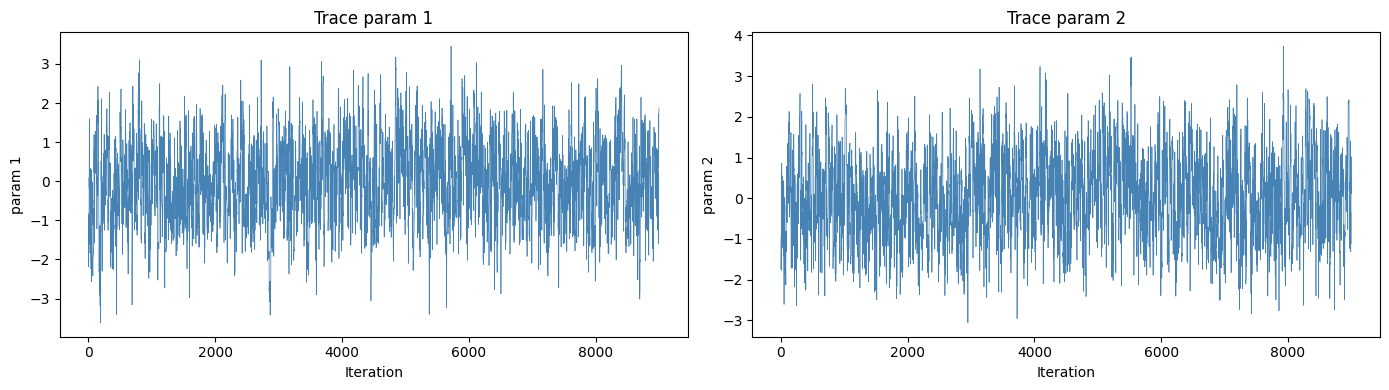

In [10]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  TASK TYPE 9 — Run a Metropolis Sampler                      ║
# ║  Only change: log_target_9 and the INPUTS block.             ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Sampler (same every exam — never change this) ─────────────
def metropolis9(log_target, theta_init, num_iter, tau, seed=42):
    np.random.seed(seed)
    D = len(theta_init)
    samples = [theta_init.copy()]; log_p = log_target(theta_init); n_acc = 0
    for _ in range(num_iter):
        prop = samples[-1] + tau * np.random.randn(D)
        lp   = log_target(prop)
        if np.log(np.random.uniform()) < lp - log_p:
            samples.append(prop); log_p = lp; n_acc += 1
        else:
            samples.append(samples[-1].copy())
    return np.array(samples), n_acc / num_iter

# ── INPUTS ───────────────────────────────────────────────────
num_iter9    = 10_000
warmup_frac9 = 0.1        # discard this fraction from the start
tau9         = 1.0        # proposal std dev — proposal cov = tau^2 * I
theta_init9  = np.array([0., 0.])   # starting point
use_two_chains9 = False   # set True for two-chain problems
chain_inits9 = [np.array([-1., 0.]), np.array([2., 5.])]

# ── YOUR LOG-TARGET — replace with your model ──────────────────
# Common patterns:
x_obs9   = 1.0   # single observation input
y_obs9   = 2.0   # single observation output
sigma2_9 = 2.0   # noise variance

def log_target_9(theta):
    w1, w2 = theta
    # Model: y = w2*tanh(w1*x) + eps,  eps~N(0,sigma2),  w~N(0,I)
    f_val  = w2 * np.tanh(w1 * x_obs9)
    log_lik= log_npdf(y_obs9, f_val, sigma2_9)
    log_pr = log_npdf(w1, 0, 1) + log_npdf(w2, 0, 1)
    return log_lik + log_pr

    # ── Other common log-targets — uncomment as needed ──────────
    # Rosenbrock (2024 exam Part 5):
    # z1, z2 = theta
    # return -(1-z1)**2 - 20*(z2-z1**2)**2 - z1**2 - z2**2

    # Two-variable: x|z~N(0,e^z), z~N(1,1) (2025 exam Part 5):
    # z, x = theta
    # return log_npdf(z,1,1) + log_npdf(x,0,np.exp(z))

    # Poisson GLM: mu=exp(3+w1*x+w2*x^2), w~N(0,1/alpha*I):
    # w1, w2 = theta; alpha=8
    # x_d=np.array([1.,2.,3.]); y_d=np.array([10,4,1])
    # X_d=np.column_stack([x_d,x_d**2])
    # mu_d=np.exp(3+X_d@np.array([w1,w2]))
    # return poisson.logpmf(y_d,mu_d).sum()+mvn.logpdf(np.array([w1,w2]),np.zeros(2),(1/alpha)*np.eye(2))

# ── RUN ───────────────────────────────────────────────────────
warmup9 = int(warmup_frac9 * num_iter9)

if not use_two_chains9:
    samp9, acc9 = metropolis9(log_target_9, theta_init9, num_iter9, tau9)
    posterior9  = samp9[warmup9:]
    print(f"Acceptance rate: {acc9:.2f}")
else:
    results9 = [metropolis9(log_target_9, init, num_iter9, tau9, seed=i)
                for i, init in enumerate(chain_inits9)]
    for i,(s,a) in enumerate(results9): print(f"Chain {i+1} acceptance rate: {a:.2f}")
    posterior9 = np.vstack([s[warmup9:] for s,_ in results9])

print(f"Posterior samples: {len(posterior9)}")

# Trace plots
D9   = posterior9.shape[1]
fig, axes = plt.subplots(1, D9, figsize=(7*D9, 4))
if D9 == 1: axes = [axes]
for i, ax in enumerate(axes):
    if use_two_chains9:
        n = (num_iter9 - warmup9)
        ax.plot(results9[0][0][warmup9:, i], lw=0.5, label='Chain 1')
        ax.plot(results9[1][0][warmup9:, i], lw=0.5, label='Chain 2', alpha=0.7)
        ax.legend()
    else:
        ax.plot(posterior9[:, i], lw=0.5, color='steelblue')
    ax.set(xlabel='Iteration', ylabel=f'param {i+1}', title=f'Trace param {i+1}')
plt.tight_layout(); plt.show()


## Task Type 10 — Grid Approximation

### What the question looks like
- *"Use the grid approximation to estimate the posterior mean and variance of $w_1$"*
- *"Use the grid approximation to estimate $p(y^*|y, x^*)$"*

**Appears in:** May 2025 Q2.1–2.2

---

### Universal recipe

The grid gives you a discrete probability distribution as a table of $(w_1, w_2, q)$ values. First read the table carefully from the figure — only non-zero cells matter.

### Posterior mean and variance of $w_1$
$$\boxed{\mathbb{E}[w_1|y] = \sum_{w_1,w_2} w_1\, q(w_1,w_2)}$$
$$\boxed{\mathbb{V}[w_1|y] = \sum_{w_1,w_2} (w_1 - \mathbb{E}[w_1|y])^2\, q(w_1,w_2)}$$

**Tip:** Group by $w_1$ value first. For each distinct $w_1$, sum all probabilities over $w_2$ to get the marginal $q(w_1)=\sum_{w_2} q(w_1,w_2)$. Then mean $= \sum_{w_1} w_1\cdot q(w_1)$.

### Posterior predictive from grid
$$\boxed{p(y^*|y,x^*) \approx \sum_{w_1,w_2} \mathcal{N}(y^*|f(x^*,w_1,w_2),\sigma^2)\cdot q(w_1,w_2)}$$

Steps: for each grid cell, evaluate the Gaussian likelihood at $y^*$ and multiply by the grid probability, then sum.

```python
# Grid as array of (w1, w2, prob)
post_pred = sum([npdf(y_star, f(x_star,w1,w2), sigma2)*p for w1,w2,p in grid])
```

---

### Common mistakes
- Not checking that probabilities sum to 1 (if they don't, you misread the table)
- Computing mean of $w_1$ as `np.mean(w1_values)` — this is wrong; must weight by probabilities

In [11]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  TASK TYPE 10 — Grid Approximation                           ║
# ╚══════════════════════════════════════════════════════════════╝

# ── INPUTS — read from the exam figure ───────────────────────
# Each row: (w1, w2, probability)
grid10 = np.array([
    (0.5, 0.2, 0.12), (0.5, 0.3, 0.09),
    (0.6, 0.1, 0.12), (0.6, 0.2, 0.20), (0.6, 0.3, 0.12),
    (0.7, 0.1, 0.23), (0.7, 0.2, 0.12),
])
sigma2_10   = 0.5   # likelihood noise variance
y_star_10   = 4.0   # y* to evaluate
x_star_10   = 4.0   # test input x*

# Model function — change to match your exam
f10 = lambda w1, w2, x: np.exp(w1 + w2*x)

# ── CALCULATION ──────────────────────────────────────────────
w1s, w2s, probs = grid10[:,0], grid10[:,1], grid10[:,2]
print(f"Probabilities sum to: {probs.sum():.4f}  (should be 1.00)")
print()

# Posterior mean and variance of w1
E_w1  = np.sum(w1s * probs)
V_w1  = np.sum((w1s - E_w1)**2 * probs)
print(f"E[w1|y]    = {E_w1:.4f}")
print(f"Var[w1|y]  = {V_w1:.4f}  ->  std = {np.sqrt(V_w1):.4f}")
print()

# Posterior mean and variance of w2
E_w2  = np.sum(w2s * probs)
V_w2  = np.sum((w2s - E_w2)**2 * probs)
print(f"E[w2|y]    = {E_w2:.4f}")
print(f"Var[w2|y]  = {V_w2:.4f}  ->  std = {np.sqrt(V_w2):.4f}")
print()

# Posterior predictive p(y*|y, x*)
post_pred10 = np.sum([npdf(y_star_10, f10(w1,w2,x_star_10), sigma2_10)*p
                      for w1,w2,p in grid10])
print(f"p(y*={y_star_10}|y, x*={x_star_10}) ≈ {post_pred10:.4f}")
print()

# Show which grid cells contribute most
print("Contribution per cell:")
for w1,w2,p in grid10:
    mu_cell = f10(w1, w2, x_star_10)
    lik     = npdf(y_star_10, mu_cell, sigma2_10)
    print(f"  w1={w1}, w2={w2}: f={mu_cell:.3f}, N(y*|f,sigma2)={lik:.4f}, *p={lik*p:.4f}")


Probabilities sum to: 1.0000  (should be 1.00)

E[w1|y]    = 0.6140
Var[w1|y]  = 0.0054  ->  std = 0.0735

E[w2|y]    = 0.1860
Var[w2|y]  = 0.0054  ->  std = 0.0735

p(y*=4.0|y, x*=4.0) ≈ 0.2949

Contribution per cell:
  w1=0.5, w2=0.2: f=3.669, N(y*|f,sigma2)=0.5057, *p=0.0607
  w1=0.5, w2=0.3: f=5.474, N(y*|f,sigma2)=0.0643, *p=0.0058
  w1=0.6, w2=0.1: f=2.718, N(y*|f,sigma2)=0.1091, *p=0.0131
  w1=0.6, w2=0.2: f=4.055, N(y*|f,sigma2)=0.5625, *p=0.1125
  w1=0.6, w2=0.3: f=6.050, N(y*|f,sigma2)=0.0085, *p=0.0010
  w1=0.7, w2=0.1: f=3.004, N(y*|f,sigma2)=0.2093, *p=0.0481
  w1=0.7, w2=0.2: f=4.482, N(y*|f,sigma2)=0.4474, *p=0.0537


## Task Type 11 — Reasoning About Model Changes

### What the question looks like
- *"Explain how you expect the MAP estimate to change if $\alpha$ is increased by 10×"*
- *"Explain how $p(y^*=1|y,x^*)$ would change if the kernel switches from $k_1$ to $k_2=\frac{1}{10}k_1$"*
- *"Explain how you expect KL$[q_1^*\|p]$ to change when switching to $q_2^*$"*
- *"Suppose the new target variable is a count. How would you adapt the model?"*

**Appears in:** May 2024 Q2.6 | Aug 2024R Q1.5, Q2.5 | May 2025 Q3.6, Q4.5 | Aug 2025R Q2.5

---

### Universal recipe — answer template

These questions are always answered in 2–3 sentences following this structure:
1. **State what changes** (identify the mechanism)
2. **State the direction of effect** (increases/decreases/moves toward X)
3. **State the reason** (one sentence connecting mechanism to effect)

### Common scenarios and answers

**Increasing prior precision $\alpha$ by $c\times$:**
> The prior variance decreases by a factor $c$, making the prior tighter around zero. This acts as stronger L2 regularisation, pulling the MAP estimate closer to zero. All weight magnitudes in $\hat{w}_{\text{MAP}}$ are expected to be numerically smaller.

**Switching kernel to $k_2 = c\cdot k_1$ with $c<1$ (shrinking prior variance):**
> The prior variance $k_2(x^*,x^*)=c\cdot k_1(x^*,x^*)$ is smaller, making the GP prior more concentrated around zero. The posterior is pulled more strongly toward the prior, so predictions move toward the prior predictive of $p(y^*=1)=0.5$. The current estimate moves toward 0.5.

**Switching from mean-field family $Q_1$ to full-rank family $Q_2$:**
> Every mean-field Gaussian is also a full-rank Gaussian (diagonal covariance is a special case), so $Q_1\subset Q_2$. The optimal $q_2^*$ minimises KL over a strictly larger set, so $\text{KL}[q_2^*\|p]\leq\text{KL}[q_1^*\|p]$. The KL divergence decreases (or stays the same).

**Adapting model from binary to count data $z_n\in\{0,1,2,\ldots\}$:**
> Replace the Bernoulli likelihood with a Poisson likelihood and use the log link: $p(z_n|w,x_n)=\text{Poisson}(z_n|e^{w^Tx_n})$. The prior $w\sim\mathcal{N}(0,\lambda^{-1}I)$ stays the same. The log link ensures the rate parameter $\mu=e^{w^Tx}>0$ for any $w$.

**A kernel is stationary / isotropic?**
> Stationary means $k(x,x')$ depends only on $x-x'$. Isotropic means it depends only on $\|x-x'\|$. If the kernel has a term like $xx'$ or $\|x\|^2$, it is not stationary (absolute positions matter). If it is stationary but has separate lengthscales per dimension, it is stationary but not isotropic.

---

### Common mistakes
- Not justifying the direction — always explain *why*, not just *what*
- Confusing $Q_1\subset Q_2$ (mean-field ⊂ full-rank) with the opposite

In [12]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  TASK TYPE 11 — Reasoning About Model Changes                ║
# ║  These are conceptual — use the template below to write      ║
# ║  your answer. Code just verifies the direction numerically.  ║
# ╚══════════════════════════════════════════════════════════════╝

# ══════════════════════════════════════════════════════════════
# 11A — Effect of increasing prior precision alpha
# ══════════════════════════════════════════════════════════════
print("11A — Effect of increasing alpha (prior precision) on MAP")
print("Answer template:")
print("  The prior variance = 1/alpha decreases, making the prior")
print("  tighter around zero. This acts as stronger L2 regularisation,")
print("  pulling the MAP estimate closer to zero. All weight magnitudes")
print("  are expected to be numerically smaller.")
print()

# Numerical verification
alpha_low, alpha_high = 0.5, 5.0
Phi11 = np.array([[1.,0.,0.,0.],[1.,1.,1.,1.],[1.,2.,4.,8.],
                  [1.,4.,16.,64.],[1.,5.,25.,125.]])
y11   = np.array([1., 0.5, -0.1, -0.9, 1.1]); sigma11 = 0.2
m_low  = np.linalg.inv(alpha_low*np.eye(4)+(1/sigma11**2)*Phi11.T@Phi11) @ ((1/sigma11**2)*Phi11.T@y11)
m_high = np.linalg.inv(alpha_high*np.eye(4)+(1/sigma11**2)*Phi11.T@Phi11) @ ((1/sigma11**2)*Phi11.T@y11)
print(f"Posterior mean with alpha={alpha_low}: {np.round(m_low,4)}")
print(f"Posterior mean with alpha={alpha_high}: {np.round(m_high,4)}")
print(f"Norm decreased: {np.linalg.norm(m_low):.4f} -> {np.linalg.norm(m_high):.4f}")

# ══════════════════════════════════════════════════════════════
# 11B — Switching kernel to k2 = c * k1 (tighter prior)
# ══════════════════════════════════════════════════════════════
print()
print("11B — Effect of switching to k2 = (1/10) * k1")
print("Answer template:")
print("  The prior variance k2(x*,x*) = k1(x*,x*)/10 is 10x smaller,")
print("  making the GP prior more concentrated around zero.")
print("  The posterior is pulled more strongly toward the prior, so")
print("  p(y*=1|y,x*) moves closer to 0.5 (the prior predictive).")

# ══════════════════════════════════════════════════════════════
# 11C — Switching from mean-field Q1 to full-rank Q2
# ══════════════════════════════════════════════════════════════
print()
print("11C — KL divergence when switching Q1 (mean-field) -> Q2 (full-rank)")
print("Answer template:")
print("  Q1 is a subset of Q2 (diagonal covariance is a special case of full covariance).")
print("  So Q1 ⊂ Q2. Minimising KL over a larger set can only decrease or maintain it:")
print("  KL[q2*||p] <= KL[q1*||p]")
print("  The KL divergence decreases (or stays the same).")

# ══════════════════════════════════════════════════════════════
# 11D — Adapting model for count data
# ══════════════════════════════════════════════════════════════
print()
print("11D — Adapt model from binary to count data z_n in {0,1,2,...}")
print("Answer template:")
print("  Replace Bernoulli likelihood with Poisson + log link:")
print("  p(z_n|w,x_n) = Poisson(z_n | exp(w^T x_n))")
print("  The log link ensures the rate mu = exp(w^T x) > 0 for any w.")
print("  The prior w ~ N(0, lambda^-1 I) stays unchanged.")


11A — Effect of increasing alpha (prior precision) on MAP
Answer template:
  The prior variance = 1/alpha decreases, making the prior
  tighter around zero. This acts as stronger L2 regularisation,
  pulling the MAP estimate closer to zero. All weight magnitudes
  are expected to be numerically smaller.

Posterior mean with alpha=0.5: [ 0.947   0.2469 -0.679   0.1269]
Posterior mean with alpha=5.0: [ 0.8738  0.1526 -0.5948  0.1141]
Norm decreased: 1.1979 -> 1.0740

11B — Effect of switching to k2 = (1/10) * k1
Answer template:
  The prior variance k2(x*,x*) = k1(x*,x*)/10 is 10x smaller,
  making the GP prior more concentrated around zero.
  The posterior is pulled more strongly toward the prior, so
  p(y*=1|y,x*) moves closer to 0.5 (the prior predictive).

11C — KL divergence when switching Q1 (mean-field) -> Q2 (full-rank)
Answer template:
  Q1 is a subset of Q2 (diagonal covariance is a special case of full covariance).
  So Q1 ⊂ Q2. Minimising KL over a larger set can only decreas

## Task Type 12 — Identify or Verify the MAP

### What the question looks like
- *"Suppose you suspect a bug in the code for computing the MAP. Explain how you could verify that $\hat{w}_{\text{MAP}}$ is correct"*
- *"Use Figure 1 to visually identify the MAP estimator for $w$"*
- *"Assume $\hat{w}_{\text{MAP}} = \arg\max_w p(w|y)$..."*

**Appears in:** May 2024 Q3.1 | Aug 2024R Q4.1 (visual) | Aug 2025R Q2 (context)

---

### Universal recipe

### Verifying the MAP (pen and paper)
Give any of these three valid checks:

**Method 1 — Gradient check (most principled):**
> At a maximum, the gradient must be zero. Compute $\nabla_w\log p(w,y)$ at $\hat{w}_{\text{MAP}}$ and verify that it is numerically $\approx 0$.

**Method 2 — Perturbation check:**
> Perturb $\hat{w}_{\text{MAP}}$ by a small $\delta$ in any direction and verify that $\log p(\hat{w}+\delta,y) < \log p(\hat{w},y)$. If the objective decreases in all directions, $\hat{w}$ is a local maximum.

**Method 3 — Optimisation convergence:**
> Verify that running one more gradient ascent step from $\hat{w}_{\text{MAP}}$ does not increase the log-joint.

### Visual identification from contour plots
- **MLE**: peak of the *likelihood* panel (middle in the three-panel plot)
- **MAP**: peak of the *posterior* panel (right panel) — pulled toward origin vs MLE
- The MAP is between the MLE and the prior mean (0)

In [13]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  TASK TYPE 12 — Identify / Verify the MAP                   ║
# ╚══════════════════════════════════════════════════════════════╝

# ── INPUTS ───────────────────────────────────────────────────
# Data and model for logistic regression
X12    = np.array([[0.,0.],[1.,1.]])
y12    = np.array([0., 1.])
lam12  = 1/4
w_MAP12= 0.74077439 * np.array([1.,1.])

def log_joint12(w):
    p = sigmoid(X12 @ w)
    return np.sum(log_npdf(w, 0, 1/lam12)) + np.sum(log_ber(y12, p))

# ── CALCULATION ──────────────────────────────────────────────
# Method 1: Gradient check — should be ~0 at MAP
eps = 1e-5
grad = np.array([(log_joint12(w_MAP12 + eps*np.eye(len(w_MAP12))[i])
                 - log_joint12(w_MAP12 - eps*np.eye(len(w_MAP12))[i]))/(2*eps)
                 for i in range(len(w_MAP12))])
print(f"Gradient at w_MAP: {np.round(grad, 6)}  (should be ~0)")

# Method 2: Perturbation check — perturb in random direction
np.random.seed(0)
delta = 0.01 * np.random.randn(len(w_MAP12))
lj_map     = log_joint12(w_MAP12)
lj_perturb = log_joint12(w_MAP12 + delta)
print(f"log p(y,w_MAP)     = {lj_map:.6f}")
print(f"log p(y,w_MAP+eps) = {lj_perturb:.6f}")
print(f"Decreased after perturbation: {lj_perturb < lj_map}  (should be True)")
print()
print("Written answer:")
print("  Since w_MAP is the MAP estimator, the gradient of log p(y,w)")
print("  must be zero at w_MAP (first-order condition for a maximum).")
print("  Verify: compute gradient numerically and check it is ~0.")
print("  Or: perturb w_MAP slightly and verify log p(y,w) decreases.")


Gradient at w_MAP: [0. 0.]  (should be ~0)
log p(y,w_MAP)     = -4.259310
log p(y,w_MAP+eps) = -4.259386
Decreased after perturbation: True  (should be True)

Written answer:
  Since w_MAP is the MAP estimator, the gradient of log p(y,w)
  must be zero at w_MAP (first-order condition for a maximum).
  Verify: compute gradient numerically and check it is ~0.
  Or: perturb w_MAP slightly and verify log p(y,w) decreases.


## Task Type 13 — Identify the Model (Prior, Likelihood, Link Function)

### What the question looks like
- *"Identify the prior and likelihood of the model"*
- *"Determine the value of the magnitude and lengthscale hyperparameters"*
- *"Determine whether $k_2$ is a stationary kernel"*
- *"Determine the likelihood for the regression model"*

**Appears in:** May 2024 Q2.1, Q2.6 | Aug 2024R Q1.1, Q2.1 | May 2025 Q1.1 | Aug 2025R Q2.5

---

### Universal recipe

### Reading off prior and likelihood
Look at the model definition and match each line to standard distributions:

| Model line | Distribution type |
|------------|------------------|
| $y_n|x_n,w\sim\text{Ber}(\sigma(w^Tx_n))$ | Likelihood: Bernoulli with logistic link |
| $y_n|x_n,w\sim\text{Cat}(\text{softmax}(W\phi(x_n)))$ | Likelihood: Categorical with softmax |
| $y_n|w,x_n\sim\text{Poisson}(e^{w^Tx_n})$ | Likelihood: Poisson with log link |
| $y_n=w^T\phi(x_n)+\epsilon_n$, $\epsilon_n\sim\mathcal{N}(0,\sigma^2)$ | Likelihood: $\mathcal{N}(y_n|w^T\phi(x_n),\sigma^2)$ |
| $W_{ij}\sim\mathcal{N}(0,\alpha^{-1})$ | Prior: iid Gaussian, i.e. $p(W)=\prod_{ij}\mathcal{N}(W_{ij}|0,\alpha^{-1})$ |
| $w\sim\mathcal{N}(0,\alpha^{-1}I)$ | Prior: multivariate Gaussian |

### Identifying kernel hyperparameters
Match the given kernel to the standard form $\kappa^2\exp(-\|x-x'\|^2/2\ell^2)$:

1. Match the **amplitude**: coefficient in front of $\exp(\cdot)$ equals $\kappa^2$
2. Match the **exponent**: $-\frac{1}{8}\|x-x'\|^2 = -\frac{\|x-x'\|^2}{2\ell^2}$ → $2\ell^2=8$ → $\ell=2$

General rule: if exponent is $-c\|x-x'\|^2$, then $c=1/(2\ell^2)$ → $\ell=1/\sqrt{2c}$.

### Checking stationarity and isotropy
- **Stationary**: does $k(x,x')$ depend only on $x-x'$? Test by checking if shift $k(x+a,x'+a)=k(x,x')$. Any term like $xx'$ or $\|x\|^2$ breaks stationarity.
- **Isotropic**: depends only on $\|x-x'\|$. All standard kernels (SE, Matérn) are isotropic. ARD is stationary but not isotropic.
- **Isotropic implies stationary** (but not vice versa).

In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  TASK TYPE 13 — Identify the Model                          ║
# ╚══════════════════════════════════════════════════════════════╝

# ══════════════════════════════════════════════════════════════
# 13A — Identify kernel hyperparameters kappa and ell
# ══════════════════════════════════════════════════════════════
print("=" * 60)
print("13A — Identify kappa and ell from kernel expression")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
# Given kernel: k(x,x') = AMPLITUDE * exp(EXPONENT * ||x-x'||^2)
# Standard form: kappa^2 * exp(-||x-x'||^2 / (2*ell^2))
amplitude_given = 2.0    # the coefficient in front of exp(...)
exponent_given  = -1/8   # the coefficient of ||x-x'||^2  (negative!)
# ── CALCULATION ──────────────────────────────────────────────
kappa_id = np.sqrt(amplitude_given)
ell_id   = np.sqrt(-1 / (2 * exponent_given))
print(f"Given: k = {amplitude_given} * exp({exponent_given} * ||x-x'||^2)")
print(f"Standard: kappa^2 * exp(-||x-x'||^2 / (2*ell^2))")
print(f"  kappa^2 = {amplitude_given}  =>  kappa = sqrt({amplitude_given}) = {kappa_id:.4f}")
print(f"  1/(2*ell^2) = {-exponent_given}  =>  ell^2 = {-1/(2*exponent_given):.4f}  =>  ell = {ell_id:.4f}")
print()
# Verify
test_d = 2.0
direct_k  = amplitude_given * np.exp(exponent_given * test_d**2)
formula_k = kappa_id**2 * np.exp(-test_d**2/(2*ell_id**2))
print(f"Verify at ||x-x'||={test_d}: direct={direct_k:.6f}, formula={formula_k:.6f}  (match: {np.isclose(direct_k,formula_k)})")

# ══════════════════════════════════════════════════════════════
# 13B — Check stationarity and isotropy of a kernel
# ══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("13B — Stationarity and isotropy check")
print("=" * 60)
# ── INPUTS ───────────────────────────────────────────────────
# Example: k2(x,x') = (1 + ||x-x'|| / (2*ell^2))^{-1} + c2*x*x'
c1_id, c2_id, ell_id2 = 1.0, 1.0, 1/np.sqrt(2)
k2_id = lambda x1, x2: c1_id*(1 + abs(x1-x2)/(2*ell_id2**2))**(-1) + c2_id*x1*x2
# ── TEST ─────────────────────────────────────────────────────
x1, x2, shift = 1.0, 3.0, 5.0
k_orig    = k2_id(x1, x2)
k_shifted = k2_id(x1+shift, x2+shift)
print(f"k2({x1},{x2}) = {k_orig:.4f}")
print(f"k2({x1+shift},{x2+shift}) = {k_shifted:.4f}  (shifted by {shift})")
print(f"Stationary (k_orig == k_shifted): {np.isclose(k_orig, k_shifted)}")
print()
if not np.isclose(k_orig, k_shifted):
    print("  NOT stationary — the c2*x*x' term depends on absolute positions.")
    print("  NOT isotropic (fails stricter requirement).")
else:
    print("  Stationary. Now check isotropy: does it depend only on ||x-x'||?")


13A — Identify kappa and ell from kernel expression
Given: k = 2.0 * exp(-0.125 * ||x-x'||^2)
Standard: kappa^2 * exp(-||x-x'||^2 / (2*ell^2))
  kappa^2 = 2.0  =>  kappa = sqrt(2.0) = 1.4142
  1/(2*ell^2) = 0.125  =>  ell^2 = 4.0000  =>  ell = 2.0000

Verify at ||x-x'||=2.0: direct=1.213061, formula=1.213061  (match: True)

13B — Stationarity and isotropy check
k2(1.0,3.0) = 3.3333
k2(6.0,8.0) = 48.3333  (shifted by 5.0)
Stationary (k_orig == k_shifted): False

  NOT stationary — the c2*x*x' term depends on absolute positions.
  NOT isotropic (fails stricter requirement).


## Task Type 14 — Decision Theory

### What the question looks like
- *"Compute the expected utility for each decision $\hat{y}\in\{0,1\}$ and determine the optimal decision"*

**Appears in:** May 2024 Q3.5

---

### Universal recipe

**Step 1 — Read the utility matrix $U$ and the predictive distribution $p(y^*|y,x^*)$.**

**Step 2 — Compute expected utility for each possible decision $\hat{y}$:**
$$\boxed{\mathbb{E}[U(y^*,\hat{y}=k)] = \sum_{j} p(y^*=j|y,x^*)\cdot U(j,k)}$$

In matrix form: `EU = p_pred @ U` gives a vector of expected utilities for each decision.

**Step 3 — Choose the decision with the highest expected utility:**
$$\hat{y}^* = \arg\max_k \mathbb{E}[U(y^*,\hat{y}=k)]$$

Code:
```python
p = np.array([p_y0, p_y1])      # predictive probabilities
U = np.array([[U00, U01],        # U[true, decision]
              [U10, U11]])
EU = np.array([p @ U[:,k] for k in range(len(p))])
best = np.argmax(EU)
```

---

### Key facts
- If $U$ is the 0/1 loss matrix (correct=1, wrong=0), the optimal decision is simply to pick the most probable class: $\hat{y}^*=\arg\max_k p(y^*=k)$
- Scaling $U$ by a positive constant does not change the optimal decision
- If one class has a much higher true-positive utility, the decision boundary shifts toward predicting that class more often

---

### Common mistakes
- Reading the utility matrix in the wrong orientation (rows = true $y$, columns = decision $\hat{y}$)
- Comparing utilities instead of expected utilities

In [15]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  TASK TYPE 14 — Decision Theory                             ║
# ╚══════════════════════════════════════════════════════════════╝

# ── INPUTS ───────────────────────────────────────────────────
# Posterior predictive distribution (one probability per class)
p_pred14 = np.array([1-0.129, 0.129])   # [p(y*=0), p(y*=1), ...]

# Utility matrix: U[true_class, decision_class]
U14 = np.array([[2, 1],    # true y=0: correct=2, wrong=1
                [1, 2]])   # true y=1: wrong=1, correct=2

# ── CALCULATION ──────────────────────────────────────────────
K14 = len(p_pred14)
EU14 = np.array([np.sum(p_pred14 * U14[:, k]) for k in range(K14)])

print("Expected utility for each decision:")
for k in range(K14):
    terms = " + ".join([f"{p_pred14[j]:.3f}*{U14[j,k]}" for j in range(K14)])
    print(f"  E[U(y*, hat_y={k})] = {terms} = {EU14[k]:.4f}")

print()
print(f"Optimal decision: hat_y = {np.argmax(EU14)}  (EU = {np.max(EU14):.4f})")
print()
print("Decision rule for 0/1 utility: pick the most probable class.")
print(f"  Most probable class = {np.argmax(p_pred14)}")


Expected utility for each decision:
  E[U(y*, hat_y=0)] = 0.871*2 + 0.129*1 = 1.8710
  E[U(y*, hat_y=1)] = 0.871*1 + 0.129*2 = 1.1290

Optimal decision: hat_y = 0  (EU = 1.8710)

Decision rule for 0/1 utility: pick the most probable class.
  Most probable class = 0


---
## Master Lookup Table — Every Exam Question by Task Type

| Task Type | May 2024 | Aug 2024R | May 2025 | Aug 2025R |
|-----------|----------|-----------|----------|-----------|
| **1. Determine a distribution** | Q1.1, 1.2, 1.3, 2.1, 4.1–4.2 | Q2.2, 2.3 | Q1.1, 1.3, 3.1, 3.2, 4.1 | Q1.1, 1.2, 1.3, 3.1, 3.2 |
| **2. Compute predictive distribution** | Q2.2, 2.3, 2.5, 3.2, 3.4 | Q1.2, 1.3 | Q1.4, 2.2, 3.5, 4.2, 4.3, 4.4 | Q2.1, 2.4, 4.3, 4.4, 4.6, 5.3 |
| **3. Compute MLE** | (Q3, implied) | Q3.1 | Q1.2 | Q2 (visual) |
| **4. Log joint / log marginal likelihood** | Q2.4 | Q3.2, 3.3, 3.4, 5.2 | — | Q2.2 |
| **5. Credibility interval / tail prob** | Q3.3 | Q4.4 | Q3.4, 4.1, 4.2 | Q4.1, 4.2 |
| **6. Hessian / Laplace** | Q3.4 | Q5.3, 5.4 | — | Q2.3, 2.4 |
| **7. Entropy / confidence** | Q4.1 | Q1.4 | Q3.3 | Q4.5 |
| **8. MC estimation from samples** | Q5.3, 5.4 | Q4.4, 4.5, 4.6, 5.2, 5.3 | Q5.2, 5.3 | Q4.6, 5.2, 5.3 |
| **9. Run Metropolis sampler** | Q5.2 | Q4.3 | Q5.1 | Q5.1 |
| **10. Grid approximation** | — | — | Q2.1, 2.2 | — |
| **11. Reasoning about model changes** | Q2.6 | Q1.5, Q2.5 | Q3.6, 4.5 | Q2.5 |
| **12. Identify / verify MAP** | Q3.1 | Q4.1 | — | Q2 (context) |
| **13. Identify the model** | Q2.1, 2.6 | Q1.1, 2.1 | Q1.1 | Q2.5 |
| **14. Decision theory** | Q3.5 | — | — | — |

---

## Frequency count — most common task types across all 4 exams

| Rank | Task Type | Total questions |
|------|-----------|----------------|
| 1 | **Compute predictive distribution** | ~18 questions |
| 2 | **MC estimation from samples** | ~12 questions |
| 3 | **Determine a distribution** | ~12 questions |
| 4 | **Run Metropolis sampler** | 4 questions (1 per exam) |
| 5 | **Credibility interval / tail probability** | ~6 questions |
| 6 | **Reasoning about model changes** | ~6 questions |
| 7 | **Log joint / marginal likelihood** | ~5 questions |
| 8 | **Entropy / confidence** | 4 questions |
| 9 | **Hessian / Laplace** | ~4 questions |
| 10 | **Compute MLE** | ~3 questions |
| 11 | **Identify the model** | ~4 questions |
| 12 | **Grid approximation** | 2 questions |
| 13 | **Identify / verify MAP** | ~3 questions |
| 14 | **Decision theory** | 1 question |

**The top 3 task types account for roughly half of all exam questions. If you can fluently execute Types 1, 2, and 8, you cover the majority of the exam.**